# IEMOCAP Dataset Analysis and Speaker-Independent Splits

Notebook này là bước đầu tiên cho hướng **Emotion2Vec-Guided Acoustic Cross-Attention Multi-Task SER**.

Mục tiêu của notebook:

1. Đọc và chuẩn hóa metadata từ IEMOCAP.
2. Kiểm tra cấu trúc dataset: session, speaker, utterance, file audio, categorical emotion, Valence, Arousal, Dominance.
3. Trực quan hóa phân bố dữ liệu để biết dataset có lệch class/speaker/session hay không.
4. Tạo hai bộ split chính cho các notebook train sau:
   - `5-fold leave-one-session-out`.
   - `10-fold speaker-independent`, dạng 8 speakers train, 1 speaker validation, 1 speaker test.
5. Lưu metadata và split files ra thư mục `06_w2v_based_models`.

Notebook này **không train model**. Nó chỉ chuẩn bị dữ liệu và split để tránh speaker leakage ngay từ đầu.

## 1. Dataset Expected Structure

Notebook này kỳ vọng dataset IEMOCAP ở dạng gốc:

```text
IEMOCAP/
  Session1/
    dialog/
      EmoEvaluation/*.txt
    sentences/
      wav/**/*.wav
  Session2/
  Session3/
  Session4/
  Session5/
```

Các file `EmoEvaluation/*.txt` chứa categorical emotion và dimensional labels:

```text
[start - end] utterance_id emotion [valence, arousal, dominance]
```

Setting mặc định dùng 4-class phổ biến:

```text
neutral, angry, sad, happy
```

Trong đó `hap` và `exc` được gộp thành `happy`.

## 2. Vì sao IEMOCAP full khoảng 10k nhưng benchmark thường còn 5,531 utterances?

IEMOCAP gốc có khoảng **10,039 utterances** từ 5 session, mỗi session gồm 2 actor. Dataset có nhiều nhãn categorical như:

```text
neu, ang, sad, hap, exc, fru, xxx, oth, ...
```

Tuy nhiên các bài Speech Emotion Recognition trên IEMOCAP thường không dùng toàn bộ nhãn gốc. Setting phổ biến nhất là **4-class SER subset**:

```text
neutral, angry, sad, happy
```

Trong đó:

```text
neu -> neutral
ang -> angry
sad -> sad
hap + exc -> happy
```

Các nhãn như `fru`, `xxx`, `oth` thường bị loại khỏi benchmark 4-class. Vì vậy số record giảm từ khoảng 10k xuống còn khoảng **5,531 utterances**. Đây không phải lỗi mất dữ liệu, mà là cách lọc benchmark để các bài báo có thể so sánh công bằng hơn trên một tập nhãn chuẩn.

Với đề tài hiện tại, notebook vẫn lưu metadata full, nhưng file train-ready mặc định dùng 4-class + AVD để phù hợp với các baseline như emotion2vec, CA-MSER, FT-w2v2, DST và nhiều paper SER khác.

## 3. Giải thích 5-fold, 10-fold và các metric cần dùng

### 3.1 5-fold leave-one-session-out là gì?

IEMOCAP có 5 session:

```text
Session1, Session2, Session3, Session4, Session5
```

Mỗi session có 2 speakers. Với **5-fold leave-one-session-out**, mỗi fold giữ lại 1 session làm test:

```text
Fold 1: test Session1, train các session còn lại
Fold 2: test Session2, train các session còn lại
...
Fold 5: test Session5, train các session còn lại
```

Trong notebook này, để có validation rõ ràng, mỗi fold dùng:

```text
test = 1 session
validation = 1 session khác
train = 3 session còn lại
```

Lý do dùng 5-fold: đây là protocol phổ biến trong SER trên IEMOCAP, giúp đánh giá model trên session/speaker chưa thấy. Nó khó hơn random split vì không trộn cùng speaker vào cả train và test.

### 3.2 10-fold speaker-independent là gì?

IEMOCAP có 10 speakers:

```text
Ses01F, Ses01M, ..., Ses05F, Ses05M
```

Với **10-fold speaker-independent**, mỗi fold giữ lại 1 speaker làm test. Notebook này dùng setting nghiêm ngặt:

```text
8 speakers train
1 speaker validation
1 speaker test
```

Lý do dùng 10-fold: đây là cách đánh giá chặt hơn vì test speaker hoàn toàn chưa xuất hiện trong train. Nếu mô hình vẫn tốt ở split này, ta có bằng chứng tốt hơn rằng model học tín hiệu cảm xúc thay vì học đặc điểm riêng của người nói.

### 3.3 Vì sao cần cả 5-fold và 10-fold?

- 5-fold giúp so sánh với nhiều bài SER cũ trên IEMOCAP.
- 10-fold giúp đánh giá speaker-independent nghiêm ngặt hơn.
- Nếu kết quả random split cao nhưng 5-fold/10-fold thấp, model có thể đang phụ thuộc speaker hoặc corpus bias.
- Với đề tài này, **10-fold speaker-independent nên là benchmark chính**, còn 5-fold là benchmark phụ để so sánh với paper.

### 3.4 WA/WAR, UA/UAR và Macro-F1 là gì?

Các metric cho emotion classification:

| Metric | Tên khác | Ý nghĩa | Khi nào quan trọng |
|---|---|---|---|
| WA | WAR / weighted average recall / accuracy | Tỉ lệ dự đoán đúng tổng thể, có ảnh hưởng bởi class nhiều mẫu | Dùng để biết performance tổng thể |
| UA | UAR / unweighted average recall / balanced accuracy | Trung bình recall của từng class | Quan trọng khi dataset lệch class |
| Macro-F1 | macro averaged F1 | Trung bình F1 của từng class, coi các class ngang nhau | Hữu ích khi muốn tránh model chỉ tốt ở class lớn |
| Weighted-F1 | weighted averaged F1 | F1 có trọng số theo số mẫu mỗi class | Gần với performance tổng thể hơn Macro-F1 |

Với IEMOCAP, dataset bị lệch class, nên **UA/UAR và Macro-F1 thường quan trọng hơn accuracy đơn thuần**.

### 3.5 CCC là gì?

CCC là **Concordance Correlation Coefficient**. Đây là metric phổ biến cho regression Valence/Arousal/Dominance.

CCC đo không chỉ correlation giữa prediction và ground truth, mà còn xem prediction có khớp về mean và variance không. Công thức:

```text
CCC = 2 * cov(y_true, y_pred) /
      (var(y_true) + var(y_pred) + (mean(y_true) - mean(y_pred))^2)
```

Ý nghĩa:

```text
CCC = 1     dự đoán khớp rất tốt
CCC = 0     gần như không concordance
CCC < 0     dự đoán đi ngược xu hướng ground truth
```

Với AVD regression, nên báo cáo:

```text
CCC-Valence
CCC-Arousal
CCC-Dominance
Mean CCC
MAE
RMSE
```

Không nên dùng accuracy cho Valence/Arousal/Dominance nếu ta giữ chúng là giá trị liên tục. Chỉ dùng accuracy/UAR nếu ta biến chúng thành class rời rạc như low/mid/high.

### 3.6 Valence, Arousal, Dominance nghĩa là gì?

| Dimension | IEMOCAP thường gọi | Ý nghĩa | Điểm thấp | Điểm cao |
|---|---|---|---|---|
| Valence | `EmoVal` | Mức tích cực/tiêu cực | tiêu cực, khó chịu, buồn/giận | tích cực, vui, dễ chịu |
| Arousal / Activation | `EmoAct` | Mức năng lượng/kích hoạt | bình tĩnh, mệt, ít năng lượng | kích động, mạnh, nhiều năng lượng |
| Dominance | `EmoDom` | Mức kiểm soát/áp đảo | yếu, bị động, thiếu kiểm soát | tự tin, kiểm soát, áp đảo |

IEMOCAP thường dùng scale 1-5. Khi train regression, notebook chuẩn hóa về 0-1:

```text
score_norm = (score - 1) / 4
```

## 4. Các bài báo tham chiếu, task, split và metric

Bảng này được đưa vào notebook để sau khi thống kê dataset, ta biết vì sao chọn 4-class, 5-fold/10-fold và metric WA/UA/CCC.

| Paper / repo | Task | Input chính | Split IEMOCAP | Emotion metric | AVD metric | Kết quả được dùng làm mốc |
|---|---|---|---|---|---|---|
| [emotion2vec: Self-Supervised Pre-Training for Speech Emotion Representation](https://arxiv.org/abs/2312.15185), repo [ddlBoJack/emotion2vec](https://github.com/ddlBoJack/emotion2vec) | Emotion classification | raw speech -> emotion2vec | IEMOCAP 4-class, 5,531 utterances; paper/repo báo cáo LOSO và LOSpeaker variants | WA/WF1/UA tùy bảng | Không báo cáo AVD | WA khoảng 71.79-72.94%; một số starred protocol variants khoảng 74.48-77.64% |
| [Speech Emotion Recognition with Co-Attention based Multi-level Acoustic Information](https://arxiv.org/abs/2203.15326), repo [Vincent-ZHQ/CA-MSER](https://github.com/Vincent-ZHQ/CA-MSER) | Emotion classification | MFCC + spectrogram + wav2vec2 | 4-class, 5,531 utterances; leave-one-session-out và leave-one-speaker-out | WA, UA | Không báo cáo AVD | LOSO WA/UA 69.80/71.05%; LOSpeaker WA/UA 71.64/72.70% |
| [Exploring Wav2vec 2.0 fine-tuning for improved speech emotion recognition](https://arxiv.org/abs/2110.06309), repo [b04901014/FT-w2v2-ser](https://github.com/b04901014/FT-w2v2-ser) | Emotion classification | raw waveform, wav2vec2 fine-tuning | leave-one-session-out; one session test, four sessions train | UA | Không báo cáo AVD | P-TAPT mean UA 74.3% |
| [DST: Deformable Speech Transformer for Emotion Recognition](https://arxiv.org/abs/2302.13729), repo [HappyColor/DST](https://github.com/HappyColor/DST) | Emotion classification | WavLM/acoustic features | IEMOCAP 4-class leave-one-session-out | WA, UA | Không báo cáo AVD | WA 71.8%, UA 73.6% |
| [SpeechFormer](https://arxiv.org/abs/2203.03812), repo [HappyColor/SpeechFormer](https://github.com/HappyColor/SpeechFormer) | Emotion classification | spectrogram/log-Mel/wav2vec features | IEMOCAP 4-class leave-one-session-out | WA, UA | Không báo cáo AVD | Wav2vec + SpeechFormer-S khoảng WA 62.9%, UA 64.5% trong bảng đã lưu |
| [Contrastive Unsupervised Learning for Speech Emotion Recognition](https://arxiv.org/abs/2102.06357) | Continuous AVD regression | raw audio / CPC representation | IEMOCAP 5-fold CV | Không phải benchmark emotion classification chính | CCC | CCC avg 0.731; Activation 0.752, Valence 0.752, Dominance 0.691 |
| [Representation learning through cross-modal conditional teacher-student training for speech emotion recognition](https://arxiv.org/abs/2112.00158) | Continuous AVD regression | HuBERT audio student, audio+text teacher | 5-fold speaker-independent CV | Không phải benchmark emotion classification chính | CCC | audio-only T/S CCC: Activation 0.667, Valence 0.582, Dominance 0.545 |
| [Learning Arousal-Valence Representation from Categorical Emotion Labels of Speech](https://arxiv.org/abs/2311.14816) | Arousal/Valence prediction | WavLM + categorical emotion classifier | speaker-independent train/test; 4/5/9 emotion configs | Emotion classifier dùng làm trung gian | CCC cho V/A | 4-emotion: Valence CCC 0.529, Arousal CCC 0.632; 9-emotion: Valence CCC 0.566, Arousal CCC 0.672 |
| [Attention-Augmented End-to-End Multi-Task Learning for Emotion Prediction from Speech](https://arxiv.org/abs/1903.12424) | AVD low/mid/high classification | raw audio / eGeMAPS baselines | train Session 1-3, dev Session 4, test Session 5 | Không phải 4-class emotion chính | UAR vì AVD bị rời rạc hóa | Test UAR: Arousal 48.5%, Valence 63.8%, Dominance 51.6% |
| [A Multi-Task, Multi-Modal Approach for Predicting Categorical and Dimensional Emotions](https://arxiv.org/abs/2401.00536) | Joint emotion classification + dimensional prediction | HuBERT acoustic + DeBERTa text | 10-fold validation, theo guideline 8 speakers train, 1 validation, 1 test | UAR/WAR | CCC cho Valence/Arousal | best UAR 75.79%, WAR 74.69%, Valence CCC 0.748, Arousal CCC 0.685; không báo cáo Dominance chính |

Ghi chú quan trọng:

- Các số trên không hoàn toàn so sánh trực tiếp nếu split khác nhau.
- Với đề tài hiện tại, ta nên báo cáo riêng 5-fold và 10-fold.
- Emotion classification dùng WA/UA/Macro-F1.
- AVD regression dùng CCC/MAE/RMSE.
- Paper nào chỉ làm categorical emotion thì không có CCC.
- Paper nào làm AVD regression thì thường không có emotion accuracy, trừ multi-task paper.

In [1]:
from pathlib import Path
import os
import re
import json
import wave
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name != "Speech Project" and PROJECT_ROOT.parent.name == "Speech Project":
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()

NOTEBOOK_DIR = PROJECT_ROOT / "06_w2v_based_models" / "01IEMOCAP Dataset Analysis and Speaker-Independent Splits"
METADATA_DIR = NOTEBOOK_DIR / "metadata"
SPLIT_DIR = NOTEBOOK_DIR / "splits"
REPORT_DIR = NOTEBOOK_DIR / "reports"
FIGURE_DIR = NOTEBOOK_DIR / "figures"

for folder in [METADATA_DIR, SPLIT_DIR, REPORT_DIR, FIGURE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("Output folders:")
for folder in [METADATA_DIR, SPLIT_DIR, REPORT_DIR, FIGURE_DIR]:
    print(" -", folder)

PROJECT_ROOT: D:\UTE\Speech Programming\Speech Project
NOTEBOOK_DIR: D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\01IEMOCAP Dataset Analysis and Speaker-Independent Splits
Output folders:
 - D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\01IEMOCAP Dataset Analysis and Speaker-Independent Splits\metadata
 - D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\01IEMOCAP Dataset Analysis and Speaker-Independent Splits\splits
 - D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\01IEMOCAP Dataset Analysis and Speaker-Independent Splits\reports
 - D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\01IEMOCAP Dataset Analysis and Speaker-Independent Splits\figures


In [2]:
reference_rows = [
    {
        "paper": "emotion2vec",
        "url": "https://arxiv.org/abs/2312.15185",
        "task": "emotion classification",
        "split": "IEMOCAP 4-class; LOSO/LOSpeaker variants",
        "emotion_metric": "WA/WF1/UA",
        "emotion_result": "WA about 71.79-72.94%; starred variants about 74.48-77.64%",
        "avd_metric": "N/A",
        "avd_result": "N/A",
    },
    {
        "paper": "CA-MSER Co-Attention",
        "url": "https://arxiv.org/abs/2203.15326",
        "task": "emotion classification",
        "split": "4-class 5,531 utterances; LOSO and LOSpeaker",
        "emotion_metric": "WA/UA",
        "emotion_result": "LOSO 69.80/71.05; LOSpeaker 71.64/72.70",
        "avd_metric": "N/A",
        "avd_result": "N/A",
    },
    {
        "paper": "FT-w2v2 P-TAPT",
        "url": "https://arxiv.org/abs/2110.06309",
        "task": "emotion classification",
        "split": "leave-one-session-out",
        "emotion_metric": "UA",
        "emotion_result": "P-TAPT mean UA 74.3%",
        "avd_metric": "N/A",
        "avd_result": "N/A",
    },
    {
        "paper": "DST",
        "url": "https://arxiv.org/abs/2302.13729",
        "task": "emotion classification",
        "split": "IEMOCAP 4-class LOSO",
        "emotion_metric": "WA/UA",
        "emotion_result": "WA 71.8%, UA 73.6%",
        "avd_metric": "N/A",
        "avd_result": "N/A",
    },
    {
        "paper": "Contrastive unsupervised learning / preCPC",
        "url": "https://arxiv.org/abs/2102.06357",
        "task": "continuous AVD regression",
        "split": "IEMOCAP 5-fold CV",
        "emotion_metric": "N/A",
        "emotion_result": "N/A",
        "avd_metric": "CCC",
        "avd_result": "avg 0.731; Act 0.752; Val 0.752; Dom 0.691",
    },
    {
        "paper": "Multi-task categorical + dimensional emotions",
        "url": "https://arxiv.org/abs/2401.00536",
        "task": "joint categorical emotion + dimensional prediction",
        "split": "10-fold: 8 speakers train, 1 validation, 1 test",
        "emotion_metric": "UAR/WAR",
        "emotion_result": "best UAR 75.79%, WAR 74.69%",
        "avd_metric": "CCC for V/A",
        "avd_result": "Valence 0.748, Arousal 0.685; no main Dominance result",
    },
]

reference_df = pd.DataFrame(reference_rows)
display(reference_df)
reference_df.to_csv(REPORT_DIR / "iemocap_reference_papers_metrics.csv", index=False, encoding="utf-8-sig")

,paper,url,task,split,emotion_metric,emotion_result,avd_metric,avd_result
0,emotion2vec,https://arxiv.org/abs/2312.15185,emotion classification,IEMOCAP 4-class; LOSO/LOSpeaker variants,WA/WF1/UA,WA about 71.79-72.94%; starred variants about 74.48-77.64%,N/A,N/A
1,CA-MSER Co-Attention,https://arxiv.org/abs/2203.15326,emotion classification,"4-class 5,531 utterances; LOSO and LOSpeaker",WA/UA,LOSO 69.80/71.05; LOSpeaker 71.64/72.70,N/A,N/A
2,FT-w2v2 P-TAPT,https://arxiv.org/abs/2110.06309,emotion classification,leave-one-session-out,UA,P-TAPT mean UA 74.3%,N/A,N/A
3,DST,https://arxiv.org/abs/2302.13729,emotion classification,IEMOCAP 4-class LOSO,WA/UA,"WA 71.8%, UA 73.6%",N/A,N/A
4,Contrastive unsupervised learning / preCPC,https://arxiv.org/abs/2102.06357,continuous AVD regression,IEMOCAP 5-fold CV,N/A,N/A,CCC,avg 0.731; Act 0.752; Val 0.752; Dom 0.691
5,Multi-task categorical + dimensional emotions,https://arxiv.org/abs/2401.00536,joint categorical emotion + dimensional prediction,"10-fold: 8 speakers train, 1 validation, 1 test",UAR/WAR,"best UAR 75.79%, WAR 74.69%",CCC for V/A,"Valence 0.748, Arousal 0.685; no main Dominance result"


In [3]:
def concordance_correlation_coefficient(y_true, y_pred, eps=1e-8):
    """CCC for one continuous target such as Valence, Arousal, or Dominance."""
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    mean_true = y_true.mean()
    mean_pred = y_pred.mean()
    var_true = y_true.var()
    var_pred = y_pred.var()
    cov = np.mean((y_true - mean_true) * (y_pred - mean_pred))
    return (2 * cov) / (var_true + var_pred + (mean_true - mean_pred) ** 2 + eps)

def metric_formula_demo():
    demo_true = np.array([0.2, 0.4, 0.7, 0.9])
    demo_pred_good = np.array([0.25, 0.42, 0.68, 0.88])
    demo_pred_shifted = np.array([0.45, 0.62, 0.88, 1.0])
    return pd.DataFrame([
        {"case": "good prediction", "CCC": concordance_correlation_coefficient(demo_true, demo_pred_good)},
        {"case": "shifted prediction", "CCC": concordance_correlation_coefficient(demo_true, demo_pred_shifted)},
    ])

display(metric_formula_demo())

,case,CCC
0,good prediction,0.992921
1,shifted prediction,0.751257


## 2. Cấu hình đường dẫn IEMOCAP

Có 3 cách để notebook tìm dataset:

1. Set biến môi trường `IEMOCAP_ROOT`.
2. Sửa trực tiếp biến `IEMOCAP_ROOT` trong cell dưới.
3. Đặt dataset vào một trong các vị trí gợi ý trong `CANDIDATE_ROOTS`.

Nếu notebook báo chưa tìm thấy IEMOCAP, phần EDA sẽ chưa chạy được. Khi đó chỉ cần sửa đường dẫn rồi chạy lại từ đầu.

In [4]:
IEMOCAP_ROOT = os.environ.get("IEMOCAP_ROOT", "").strip()

CANDIDATE_ROOTS = [
    Path(IEMOCAP_ROOT) if IEMOCAP_ROOT else None,
    PROJECT_ROOT / "IEMOCAP",
    PROJECT_ROOT / "data" / "IEMOCAP",
    PROJECT_ROOT / "datasets" / "IEMOCAP",
    PROJECT_ROOT / "Datasets" / "IEMOCAP",
    Path(r"D:\UTE\Speech Programming\Speech Project\IEMOCAP"),
    Path(r"D:\UTE\Speech Programming\Speech Project\data\IEMOCAP"),
    Path(r"D:\UTE\Speech Programming\Speech Project\datasets\IEMOCAP"),
]
CANDIDATE_ROOTS = [p for p in CANDIDATE_ROOTS if p is not None]

def looks_like_iemocap_root(path: Path) -> bool:
    if not path.exists() or not path.is_dir():
        return False
    sessions = [path / f"Session{i}" for i in range(1, 6)]
    has_sessions = sum(s.exists() for s in sessions) >= 3
    has_eval = any((s / "dialog" / "EmoEvaluation").exists() for s in sessions)
    has_wav = any((s / "sentences" / "wav").exists() for s in sessions)
    return has_sessions and has_eval and has_wav

resolved_root = None
for candidate in CANDIDATE_ROOTS:
    if looks_like_iemocap_root(candidate):
        resolved_root = candidate.resolve()
        break

if resolved_root is None:
    display(Markdown("""
### Chưa tìm thấy IEMOCAP root

Notebook chưa thấy cấu trúc IEMOCAP gốc trong các đường dẫn gợi ý.

Hãy sửa biến `IEMOCAP_ROOT`, ví dụ:

```python
IEMOCAP_ROOT = r"D:\\Datasets\\IEMOCAP"
```
"""))
else:
    IEMOCAP_ROOT = resolved_root
    print("Found IEMOCAP_ROOT:", IEMOCAP_ROOT)


### Chưa tìm thấy IEMOCAP root

Notebook chưa thấy cấu trúc IEMOCAP gốc trong các đường dẫn gợi ý.

Hãy sửa biến `IEMOCAP_ROOT`, ví dụ:

```python
IEMOCAP_ROOT = r"D:\Datasets\IEMOCAP"
```


## 3. Helper Functions

Các hàm dưới đây làm 4 việc chính:

- Parse các file `EmoEvaluation/*.txt`.
- Tìm file `.wav` tương ứng với từng utterance id.
- Suy ra `session`, `speaker_id`, `gender`, `conversation_id` từ tên utterance.
- Đọc duration của audio bằng thư viện chuẩn `wave`.

In [5]:
EVAL_PATTERN = re.compile(
    r"^\[(?P<start>[0-9.]+)\s*-\s*(?P<end>[0-9.]+)\]\s+"
    r"(?P<utterance_id>\S+)\s+"
    r"(?P<emotion>\w+)\s+"
    r"\[(?P<valence>[0-9.]+),\s*(?P<arousal>[0-9.]+),\s*(?P<dominance>[0-9.]+)\]"
)

EMOTION_NAME_MAP = {
    "neu": "neutral",
    "ang": "angry",
    "sad": "sad",
    "hap": "happy",
    "exc": "happy",
    "sur": "surprise",
    "fea": "fear",
    "dis": "disgust",
    "fru": "frustration",
    "oth": "other",
    "xxx": "unknown",
}

FOUR_CLASS_EMOTIONS = ["neutral", "angry", "sad", "happy"]

def parse_session_from_utt(utterance_id: str) -> str:
    match = re.match(r"(Ses\d{2})", utterance_id)
    return match.group(1) if match else "unknown_session"

def parse_gender_from_utt(utterance_id: str) -> str:
    last = utterance_id.split("_")[-1]
    if last.startswith("F"):
        return "female"
    if last.startswith("M"):
        return "male"
    return "unknown"

def parse_speaker_from_utt(utterance_id: str) -> str:
    session = parse_session_from_utt(utterance_id)
    gender = parse_gender_from_utt(utterance_id)
    if gender == "female":
        return f"{session}F"
    if gender == "male":
        return f"{session}M"
    return f"{session}_unknown"

def parse_conversation_id(utterance_id: str) -> str:
    parts = utterance_id.split("_")
    return "_".join(parts[:2]) if len(parts) >= 2 else utterance_id

def wav_duration_seconds(path: Path):
    try:
        with wave.open(str(path), "rb") as wav_file:
            frames = wav_file.getnframes()
            rate = wav_file.getframerate()
            channels = wav_file.getnchannels()
            return frames / float(rate), rate, channels
    except Exception:
        return np.nan, np.nan, np.nan

def build_wav_index(iemocap_root: Path) -> dict:
    wav_paths = list(iemocap_root.glob("Session*/sentences/wav/**/*.wav"))
    return {p.stem: p for p in wav_paths}

def parse_iemocap_metadata(iemocap_root: Path) -> pd.DataFrame:
    wav_index = build_wav_index(iemocap_root)
    rows = []
    eval_files = sorted(iemocap_root.glob("Session*/dialog/EmoEvaluation/*.txt"))

    for eval_path in eval_files:
        session_folder = eval_path.parts[-4] if len(eval_path.parts) >= 4 else "unknown"
        with eval_path.open("r", encoding="utf-8", errors="ignore") as file:
            for raw_line in file:
                line = raw_line.strip()
                match = EVAL_PATTERN.match(line)
                if not match:
                    continue
                item = match.groupdict()
                utterance_id = item["utterance_id"]
                wav_path = wav_index.get(utterance_id)
                duration, sample_rate, channels = wav_duration_seconds(wav_path) if wav_path else (np.nan, np.nan, np.nan)
                original_emotion = item["emotion"]
                emotion = EMOTION_NAME_MAP.get(original_emotion, original_emotion)
                rows.append({
                    "utterance_id": utterance_id,
                    "conversation_id": parse_conversation_id(utterance_id),
                    "session": parse_session_from_utt(utterance_id),
                    "session_folder": session_folder,
                    "speaker_id": parse_speaker_from_utt(utterance_id),
                    "gender": parse_gender_from_utt(utterance_id),
                    "original_emotion": original_emotion,
                    "emotion": emotion,
                    "start_time": float(item["start"]),
                    "end_time": float(item["end"]),
                    "eval_duration": float(item["end"]) - float(item["start"]),
                    "valence": float(item["valence"]),
                    "arousal": float(item["arousal"]),
                    "dominance": float(item["dominance"]),
                    "wav_path": str(wav_path) if wav_path else None,
                    "wav_found": wav_path is not None,
                    "duration": duration,
                    "sample_rate": sample_rate,
                    "channels": channels,
                    "eval_file": str(eval_path),
                })

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["session", "conversation_id", "utterance_id"]).reset_index(drop=True)
        df.insert(0, "sample_id", [f"iemocap_{i:05d}" for i in range(len(df))])
        df["is_4class"] = df["emotion"].isin(FOUR_CLASS_EMOTIONS)
        df["emotion_4class"] = df["emotion"].where(df["is_4class"], np.nan)
        df["valence_norm"] = (df["valence"] - 1.0) / 4.0
        df["arousal_norm"] = (df["arousal"] - 1.0) / 4.0
        df["dominance_norm"] = (df["dominance"] - 1.0) / 4.0
    return df

## Ghi chú về bản Hugging Face AbstractTTS/IEMOCAP

Notebook này có thể đọc hai nguồn dữ liệu:

1. **IEMOCAP gốc** với cấu trúc `Session*/dialog/EmoEvaluation` và `Session*/sentences/wav`.
2. **Bản Hugging Face [AbstractTTS/IEMOCAP](https://huggingface.co/datasets/AbstractTTS/IEMOCAP)** đã được tải về workspace.

Bản Hugging Face có 10,039 rows và đã đóng gói audio + transcript + xác suất emotion + `major_emotion` + `EmoAct`, `EmoVal`, `EmoDom`.

Điểm cần chú ý: nếu lọc 4-class theo `major_emotion` trong bản HF này thì số mẫu là khoảng **6,877**, không phải **5,531** như benchmark IEMOCAP 4-class truyền thống. Lý do là benchmark 5,531 thường dùng quy tắc lọc nhãn consensus gốc `neutral/sad/angry/happy+excited`, còn bản HF này cung cấp `major_emotion`/probability cho toàn bộ 10,039 utterances. Vì vậy khi báo cáo kết quả, cần ghi rõ:

```text
Dataset source: AbstractTTS/IEMOCAP Hugging Face
4-class rule: major_emotion in {neutral, angry, sad, happy, excited}; happy = happy + excited
```

Nếu muốn so sánh thật sát với các paper benchmark 5,531, cần kiểm tra thêm xem bản HF có cột/metadata consensus gốc tương ứng hay không. Hiện notebook giữ lại nhận xét này để tránh so sánh nhầm.

## 4. Load Metadata

Cell này parse toàn bộ IEMOCAP metadata. Nếu dataset chưa có trên máy, notebook sẽ dừng ở trạng thái thân thiện thay vì lỗi dài khó đọc.

In [6]:
HF_METADATA_FULL_PATH = PROJECT_ROOT / "06_w2v_based_models" / "datasets" / "AbstractTTS_IEMOCAP" / "abstracttts_iemocap_metadata_full.csv"

if resolved_root is None and HF_METADATA_FULL_PATH.exists():
    metadata = pd.read_csv(HF_METADATA_FULL_PATH)
    metadata["is_4class"] = metadata["emotion_4class"].notna()
    print("Loaded Hugging Face AbstractTTS/IEMOCAP metadata:", metadata.shape)
    display(Markdown("""
**Đang dùng fallback Hugging Face AbstractTTS/IEMOCAP.**

Notebook không thấy IEMOCAP root gốc, nhưng đã thấy metadata HF đã tải trong workspace.
"""))
    display(metadata.head())

    metadata_path = METADATA_DIR / "iemocap_metadata_full.csv"
    metadata.to_csv(metadata_path, index=False, encoding="utf-8-sig")
    print("Saved full metadata:", metadata_path)
elif resolved_root is None:
    metadata = pd.DataFrame()
    display(Markdown("**Dataset chưa sẵn sàng.** Hãy cấu hình `IEMOCAP_ROOT` hoặc tải Hugging Face AbstractTTS/IEMOCAP, sau đó chạy lại notebook."))
else:
    metadata = parse_iemocap_metadata(IEMOCAP_ROOT)
    print("Metadata shape:", metadata.shape)
    display(metadata.head())

    metadata_path = METADATA_DIR / "iemocap_metadata_full.csv"
    metadata.to_csv(metadata_path, index=False, encoding="utf-8-sig")
    print("Saved full metadata:", metadata_path)

Loaded Hugging Face AbstractTTS/IEMOCAP metadata: (10039, 46)



**Đang dùng fallback Hugging Face AbstractTTS/IEMOCAP.**

Notebook không thấy IEMOCAP root gốc, nhưng đã thấy metadata HF đã tải trong workspace.


,sample_id,train_sample_id,utterance_id,file,conversation_id,session,speaker_id,gender,original_emotion,emotion,emotion_4class,is_4class,emotion_id,transcription,valence,arousal,dominance,EmoAct,EmoVal,EmoDom,valence_norm,arousal_norm,dominance_norm,duration,start_time,end_time,eval_duration,sample_rate,channels,wav_path,wav_found,source_dataset,speaking_rate,pitch_mean,pitch_std,rms,relative_db,prob_frustrated,prob_angry,prob_sad,prob_disgust,prob_excited,prob_fear,prob_neutral,prob_surprise,prob_happy
0,iemocap_hf_00000,iemocap_hf_00000,Ses01F_impro01_F000,Ses01F_impro01_F000.wav,Ses01F_impro01,Ses01,Ses01F,female,neutral,neutral,neutral,True,0,Excuse me.,2.666667,2.333333,2.000000,2.333333,2.666667,2.000000,0.416667,0.333333,0.250000,1.945563,0.0,1.945563,1.945563,16000,1,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses01F_impro01_F...,True,AbstractTTS/IEMOCAP,5.14,202.798813,76.127853,0.007884,-17.938435,0.006250,0.006250,0.00625,0.006250,0.00625,0.00625,0.950000,0.00625,0.00625
1,iemocap_hf_00001,iemocap_hf_00001,Ses01F_impro01_F001,Ses01F_impro01_F001.wav,Ses01F_impro01,Ses01,Ses01F,female,neutral,neutral,neutral,True,0,Yeah.,2.333333,2.666667,2.333333,2.666667,2.333333,2.333333,0.333333,0.416667,0.333333,1.382437,0.0,1.382437,1.382437,16000,1,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses01F_impro01_F...,True,AbstractTTS/IEMOCAP,1.45,184.518967,18.823940,0.009273,-22.341549,0.006250,0.195000,0.00625,0.006250,0.00625,0.00625,0.761250,0.00625,0.00625
2,iemocap_hf_00002,iemocap_hf_00002,Ses01F_impro01_F002,Ses01F_impro01_F002.wav,Ses01F_impro01,Ses01,Ses01F,female,neutral,neutral,neutral,True,0,Is there a problem?,2.666667,2.666667,2.666667,2.666667,2.666667,2.666667,0.416667,0.416667,0.416667,3.130250,0.0,3.130250,3.130250,16000,1,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses01F_impro01_F...,True,AbstractTTS/IEMOCAP,5.11,199.979996,23.654751,0.007846,-21.383230,0.006250,0.195000,0.00625,0.006250,0.00625,0.00625,0.572500,0.19500,0.00625
3,iemocap_hf_00003,iemocap_hf_00003,Ses01F_impro01_F003,Ses01F_impro01_F003.wav,Ses01F_impro01,Ses01,Ses01F,female,neutral,neutral,neutral,True,0,You did.,2.333333,3.000000,3.000000,3.000000,2.333333,3.000000,0.333333,0.500000,0.500000,1.497500,0.0,1.497500,1.497500,16000,1,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses01F_impro01_F...,True,AbstractTTS/IEMOCAP,4.01,175.226746,20.317553,0.013659,-18.791922,0.383750,0.383750,0.00625,0.006250,0.00625,0.00625,0.195000,0.00625,0.00625
4,iemocap_hf_00004,iemocap_hf_00004,Ses01F_impro01_F004,Ses01F_impro01_F004.wav,Ses01F_impro01,Ses01,Ses01F,female,neutral,neutral,neutral,True,0,You were standing at the beginning and you directed me.,2.666667,3.333333,2.666667,3.333333,2.666667,2.666667,0.416667,0.583333,0.416667,3.414250,0.0,3.414250,3.414250,16000,1,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses01F_impro01_F...,True,AbstractTTS/IEMOCAP,13.18,166.419769,58.883690,0.029505,-14.890097,0.320833,0.320833,0.00625,0.163542,0.00625,0.00625,0.163542,0.00625,0.00625


Saved full metadata: D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\01IEMOCAP Dataset Analysis and Speaker-Independent Splits\metadata\iemocap_metadata_full.csv


## 5. Kiểm tra schema và chất lượng metadata

Phần này giúp trả lời:

- Dataset có bao nhiêu utterance?
- Có bao nhiêu session/speaker/conversation?
- Có thiếu file WAV không?
- Các cột Valence/Arousal/Dominance có nằm trong scale 1-5 không?

In [7]:
if metadata.empty:
    display(Markdown("Không có metadata để phân tích."))
else:
    schema_rows = []
    for col in metadata.columns:
        schema_rows.append({
            "column": col,
            "dtype": str(metadata[col].dtype),
            "non_null": int(metadata[col].notna().sum()),
            "missing": int(metadata[col].isna().sum()),
            "n_unique": int(metadata[col].nunique(dropna=True)),
            "example": metadata[col].dropna().iloc[0] if metadata[col].notna().any() else None,
        })
    schema_df = pd.DataFrame(schema_rows)
    display(schema_df)

    overview = pd.DataFrame([
        {"metric": "utterances", "value": len(metadata)},
        {"metric": "sessions", "value": metadata["session"].nunique()},
        {"metric": "speakers", "value": metadata["speaker_id"].nunique()},
        {"metric": "conversations", "value": metadata["conversation_id"].nunique()},
        {"metric": "wav_found_rate", "value": metadata["wav_found"].mean()},
        {"metric": "4class_utterances", "value": int(metadata["is_4class"].sum())},
        {"metric": "4class_rate", "value": metadata["is_4class"].mean()},
    ])
    display(overview)

    schema_df.to_csv(REPORT_DIR / "iemocap_schema.csv", index=False, encoding="utf-8-sig")
    overview.to_csv(REPORT_DIR / "iemocap_overview.csv", index=False, encoding="utf-8-sig")

,column,dtype,non_null,missing,n_unique,example
0,sample_id,object,10039,0,10039,iemocap_hf_00000
1,train_sample_id,object,10039,0,10039,iemocap_hf_00000
2,utterance_id,object,10039,0,10039,Ses01F_impro01_F000
3,file,object,10039,0,10039,Ses01F_impro01_F000.wav
4,conversation_id,object,10039,0,110,Ses01F_impro01
5,session,object,10039,0,5,Ses01
6,speaker_id,object,10039,0,10,Ses01F
7,gender,object,10039,0,2,female
8,original_emotion,object,10039,0,10,neutral
9,emotion,object,10039,0,10,neutral


,metric,value
0,utterances,10039.000000
1,sessions,5.000000
2,speakers,10.000000
3,conversations,110.000000
4,wav_found_rate,1.000000
5,4class_utterances,6877.000000
6,4class_rate,0.685028


## 6. Phân bố categorical emotion

IEMOCAP có nhiều label gốc, nhưng phần lớn các bài SER phổ biến dùng 4-class:

```text
neutral, angry, sad, happy/excited
```

Ta cần xem số lượng mẫu từng class để quyết định có cần class weight, weighted sampler hoặc focal loss ở notebook train hay không.

,emotion,count
0,frustrated,2917
1,excited,1976
2,neutral,1726
3,angry,1269
4,sad,1250
5,happy,656
6,surprise,110
7,fear,107
8,other,26
9,disgust,2


,emotion_4class,count
0,happy,2632
1,neutral,1726
2,angry,1269
3,sad,1250


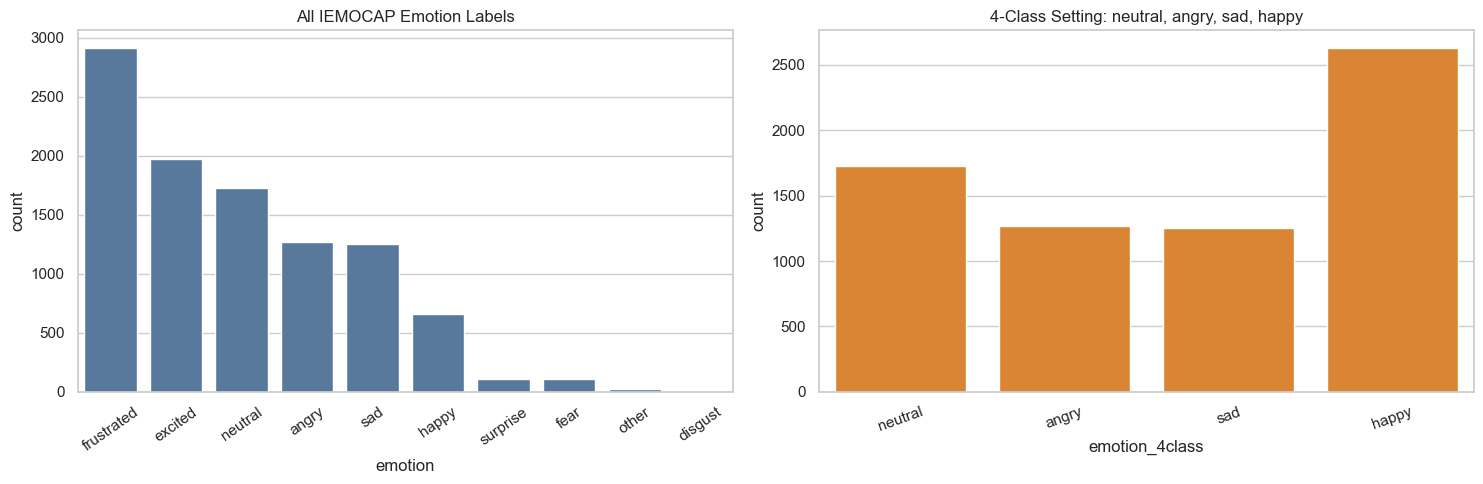

In [8]:
if metadata.empty:
    display(Markdown("Không có metadata để visualize."))
else:
    emotion_counts = metadata["emotion"].value_counts().rename_axis("emotion").reset_index(name="count")
    emotion4_counts = metadata.loc[metadata["is_4class"], "emotion_4class"].value_counts().rename_axis("emotion_4class").reset_index(name="count")
    display(emotion_counts)
    display(emotion4_counts)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.barplot(data=emotion_counts, x="emotion", y="count", ax=axes[0], color="#4C78A8")
    axes[0].set_title("All IEMOCAP Emotion Labels")
    axes[0].tick_params(axis="x", rotation=35)
    sns.barplot(data=emotion4_counts, x="emotion_4class", y="count", ax=axes[1], order=FOUR_CLASS_EMOTIONS, color="#F58518")
    axes[1].set_title("4-Class Setting: neutral, angry, sad, happy")
    axes[1].tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "emotion_distribution.png", dpi=160, bbox_inches="tight")
    plt.show()

    emotion_counts.to_csv(REPORT_DIR / "emotion_distribution_all.csv", index=False, encoding="utf-8-sig")
    emotion4_counts.to_csv(REPORT_DIR / "emotion_distribution_4class.csv", index=False, encoding="utf-8-sig")

## 7. Phân bố theo session và speaker

Phần này rất quan trọng vì đề tài hiện tại nhắm tới **speaker-independent evaluation**. Nếu split sai và cùng speaker xuất hiện ở cả train/test, kết quả có thể bị cao ảo.

emotion_4class,angry,happy,neutral,sad
session,,,,
Ses01,270,446,392,229
Ses02,151,518,362,212
Ses03,286,506,327,339
Ses04,365,549,259,159
Ses05,197,613,386,311


,emotion_4class,angry,happy,neutral,sad
speaker_id,gender,,,,
Ses01F,female,179,203,175,100
Ses01M,male,91,243,217,129
Ses02F,female,71,249,135,126
Ses02M,male,80,269,227,86
Ses03F,female,115,227,133,202
Ses03M,male,171,279,194,137
Ses04F,female,220,292,77,73
Ses04M,male,145,257,182,86
Ses05F,female,88,248,222,176


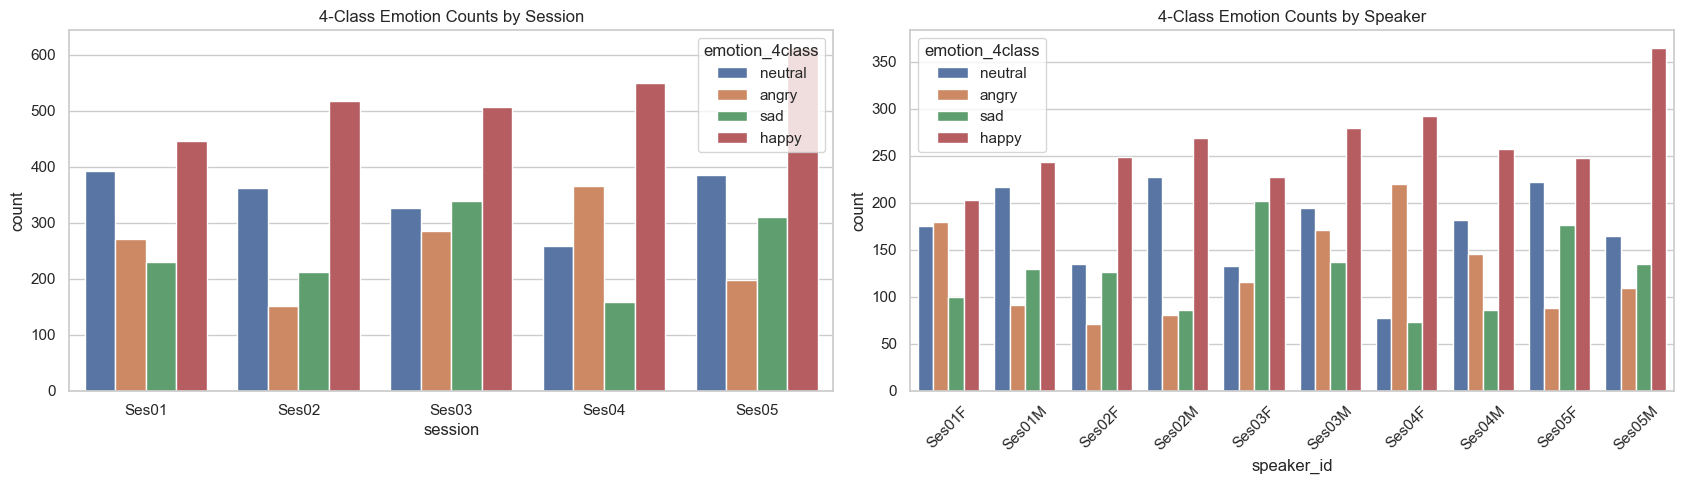

In [9]:
if metadata.empty:
    display(Markdown("Không có metadata để phân tích speaker/session."))
else:
    df4 = metadata[metadata["is_4class"]].copy()

    session_pivot = df4.pivot_table(index="session", columns="emotion_4class", values="utterance_id", aggfunc="count", fill_value=0)
    speaker_pivot = df4.pivot_table(index=["speaker_id", "gender"], columns="emotion_4class", values="utterance_id", aggfunc="count", fill_value=0)
    display(session_pivot)
    display(speaker_pivot)

    fig, axes = plt.subplots(1, 2, figsize=(17, 5))
    sns.countplot(data=df4, x="session", hue="emotion_4class", order=sorted(df4["session"].unique()), hue_order=FOUR_CLASS_EMOTIONS, ax=axes[0])
    axes[0].set_title("4-Class Emotion Counts by Session")
    sns.countplot(data=df4, x="speaker_id", hue="emotion_4class", order=sorted(df4["speaker_id"].unique()), hue_order=FOUR_CLASS_EMOTIONS, ax=axes[1])
    axes[1].set_title("4-Class Emotion Counts by Speaker")
    axes[1].tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "session_speaker_emotion_distribution.png", dpi=160, bbox_inches="tight")
    plt.show()

    session_pivot.to_csv(REPORT_DIR / "session_emotion_summary_4class.csv", encoding="utf-8-sig")
    speaker_pivot.to_csv(REPORT_DIR / "speaker_emotion_summary_4class.csv", encoding="utf-8-sig")

## 8. Duration analysis

Phân tích duration giúp quyết định chiến lược feature extraction ở notebook thứ hai.

Điểm cần quan sát:

- Audio có quá dài/quá ngắn không?
- Nếu crop cố định 3 giây như 06D cũ thì mất bao nhiêu phần trăm dữ liệu?
- Có nên dùng segmentation + pooling thay vì crop một đoạn duy nhất không?

,duration_seconds
count,6877.000000
mean,4.485509
std,3.134057
min,0.584937
5%,1.379938
25%,2.327187
50%,3.529937
75%,5.713625
90%,8.500225
95%,10.708625


,target_seconds,n_longer_than_target,rate_longer_than_target
0,3,4110,0.597644
1,4,2939,0.427367
2,5,2148,0.312345
3,8,815,0.118511
4,10,432,0.062818
5,15,86,0.012505


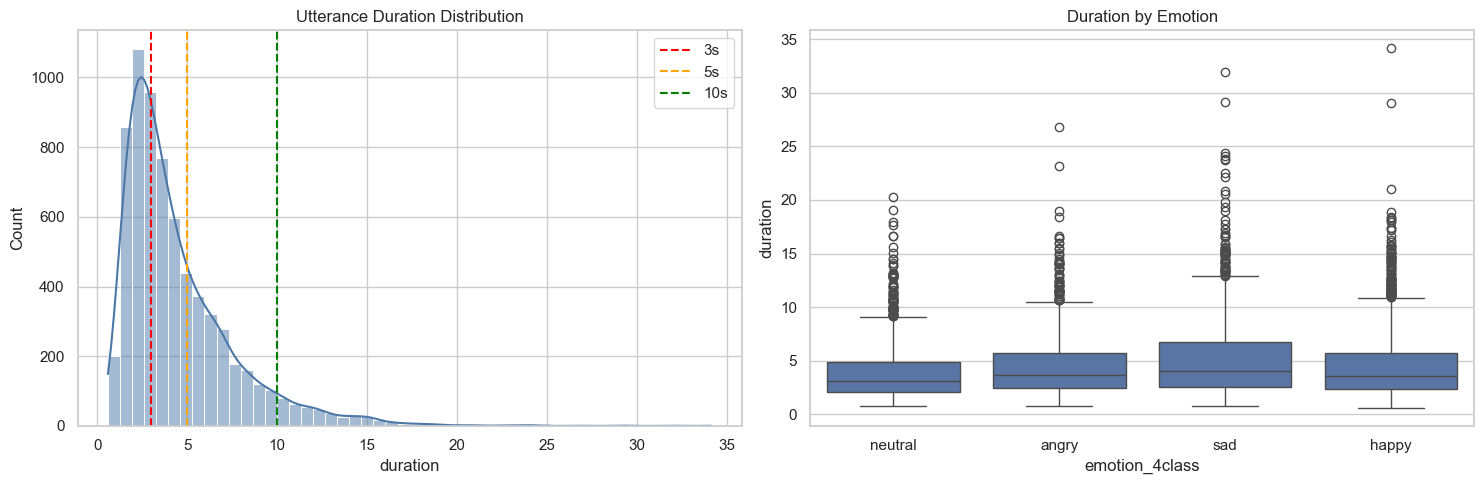

In [10]:
if metadata.empty:
    display(Markdown("Không có metadata để phân tích duration."))
else:
    df4 = metadata[metadata["is_4class"]].copy()
    duration_col = "duration" if df4["duration"].notna().any() else "eval_duration"

    duration_summary = df4[duration_col].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99]).to_frame("duration_seconds")
    display(duration_summary)

    crop_df = pd.DataFrame([
        {
            "target_seconds": sec,
            "n_longer_than_target": int((df4[duration_col] > sec).sum()),
            "rate_longer_than_target": float((df4[duration_col] > sec).mean()),
        }
        for sec in [3, 4, 5, 8, 10, 15]
    ])
    display(crop_df)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.histplot(df4[duration_col].dropna(), bins=50, kde=True, ax=axes[0], color="#4C78A8")
    for sec, color in [(3, "red"), (5, "orange"), (10, "green")]:
        axes[0].axvline(sec, color=color, linestyle="--", label=f"{sec}s")
    axes[0].set_title("Utterance Duration Distribution")
    axes[0].legend()
    sns.boxplot(data=df4, x="emotion_4class", y=duration_col, order=FOUR_CLASS_EMOTIONS, ax=axes[1])
    axes[1].set_title("Duration by Emotion")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "duration_analysis.png", dpi=160, bbox_inches="tight")
    plt.show()

    duration_summary.to_csv(REPORT_DIR / "duration_summary.csv", encoding="utf-8-sig")
    crop_df.to_csv(REPORT_DIR / "duration_crop_risk.csv", index=False, encoding="utf-8-sig")

## 9. Valence, Arousal, Dominance analysis

IEMOCAP cung cấp dimensional labels theo scale gốc 1-5:

- **Valence**: mức tích cực/tiêu cực của cảm xúc.
- **Arousal**: mức kích hoạt/năng lượng cảm xúc.
- **Dominance**: mức kiểm soát/áp đảo trong biểu hiện cảm xúc.

Trong training regression, ta thường normalize về 0-1:

```text
normalized = (score - 1) / 4
```

,count,mean,std,min,5%,25%,50%,75%,95%,max
valence,6877.0,2.975995,0.945784,1.0,1.5,2.0,3.0,4.000000,4.5,5.0
arousal,6877.0,3.078937,0.717466,1.0,2.0,2.5,3.0,3.500000,4.5,5.0
dominance,6877.0,3.170748,0.785253,1.0,2.0,2.5,3.0,3.666667,4.5,5.0


valence                                  arousal            \
                    mean       std  min       max count      mean       std   
emotion_4class                                                                
angry           1.934923  0.535577  1.0  4.333333  1269  3.599291  0.692513   
happy           3.804775  0.650618  1.5  5.000000  2632  3.285056  0.625221   
neutral         2.983584  0.500358  1.5  4.666667  1726  2.729046  0.520980   
sad             2.277333  0.598800  1.0  4.500000  1250  2.599800  0.620581   

                               dominance                            
                min  max count      mean       std  min  max count  
emotion_4class                                                      
angry           1.5  5.0  1269  3.890990  0.686062  1.0  5.0  1269  
happy           1.5  5.0  2632  3.201710  0.706489  1.0  5.0  2632  
neutral         1.0  4.5  1726  2.854046  0.590451  1.0  4.5  1726  
sad             1.0  4.5  1250  2.811667  0.766265  1.0  5.0  1250

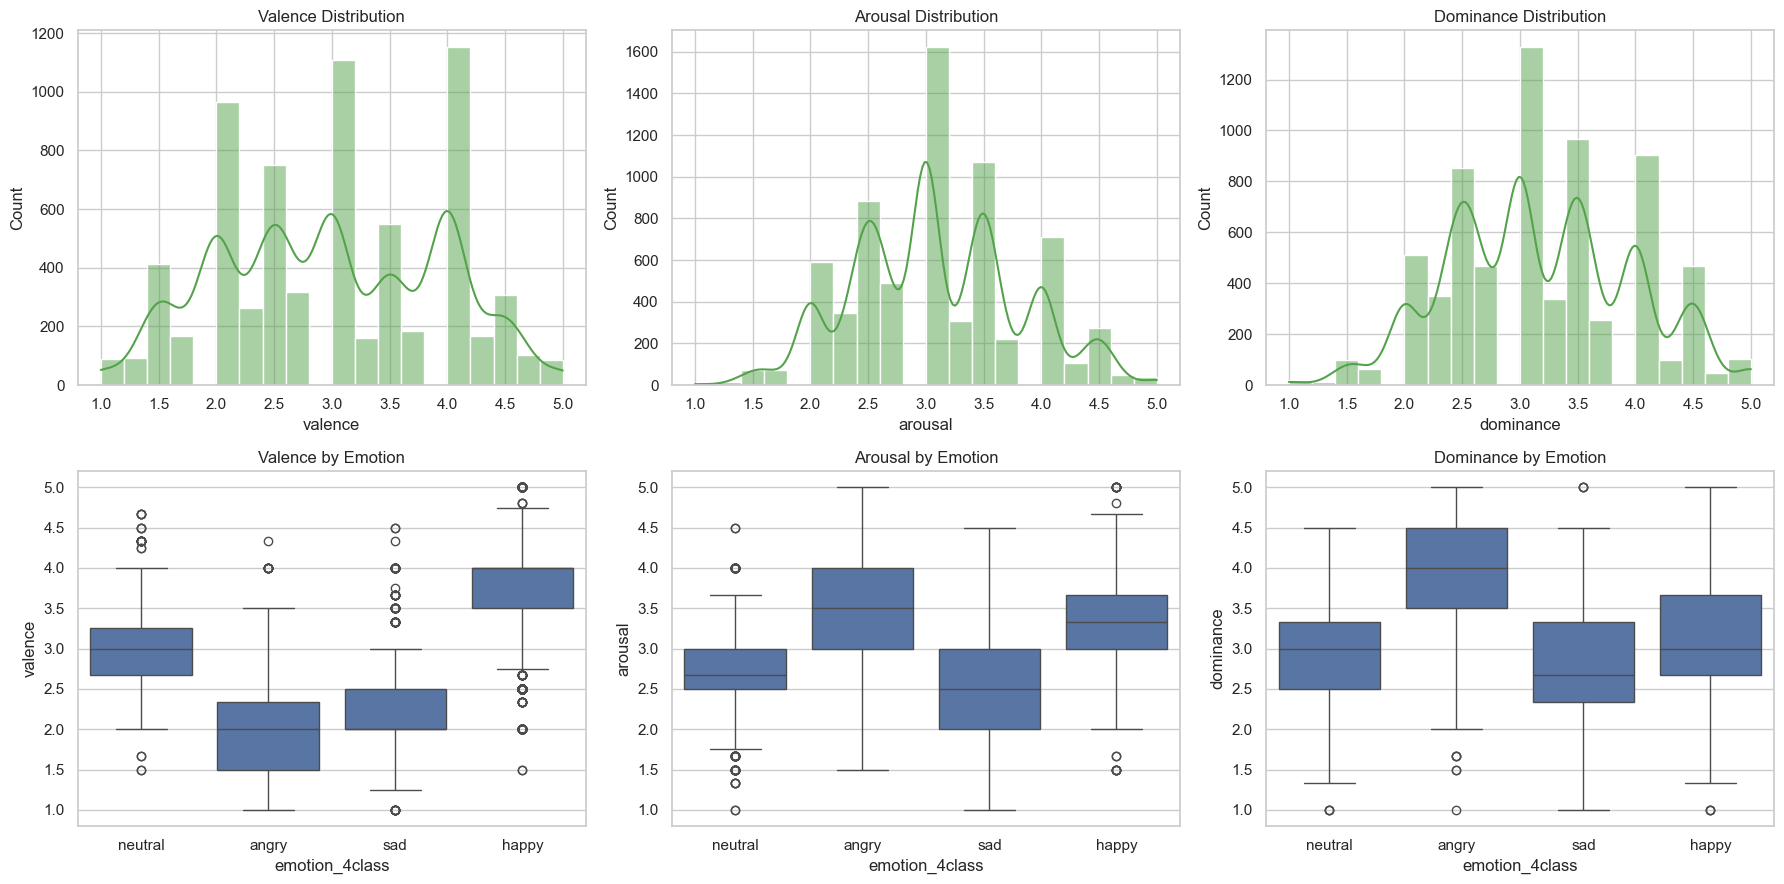

,valence,arousal,dominance
valence,1.000000,0.069229,-0.133011
arousal,0.069229,1.000000,0.617316
dominance,-0.133011,0.617316,1.000000


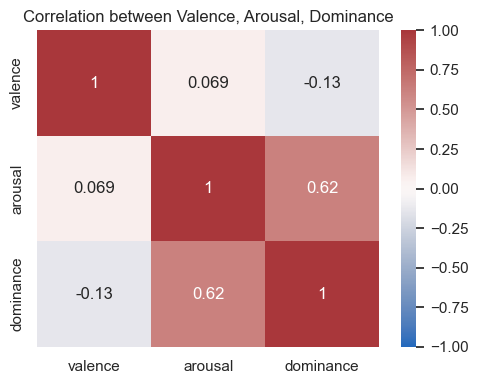

In [11]:
if metadata.empty:
    display(Markdown("Không có metadata để phân tích AVD."))
else:
    df4 = metadata[metadata["is_4class"]].copy()
    avd_cols = ["valence", "arousal", "dominance"]
    avd_summary = df4[avd_cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
    display(avd_summary)

    by_emotion_avd = df4.groupby("emotion_4class")[avd_cols].agg(["mean", "std", "min", "max", "count"])
    display(by_emotion_avd)

    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    for i, col in enumerate(avd_cols):
        sns.histplot(df4[col], bins=20, kde=True, ax=axes[0, i], color="#54A24B")
        axes[0, i].set_title(f"{col.title()} Distribution")
        sns.boxplot(data=df4, x="emotion_4class", y=col, order=FOUR_CLASS_EMOTIONS, ax=axes[1, i])
        axes[1, i].set_title(f"{col.title()} by Emotion")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "avd_distribution.png", dpi=160, bbox_inches="tight")
    plt.show()

    corr = df4[avd_cols].corr()
    display(corr)
    plt.figure(figsize=(5, 4))
    sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap="vlag")
    plt.title("Correlation between Valence, Arousal, Dominance")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "avd_correlation.png", dpi=160, bbox_inches="tight")
    plt.show()

    avd_summary.to_csv(REPORT_DIR / "avd_summary.csv", encoding="utf-8-sig")
    by_emotion_avd.to_csv(REPORT_DIR / "avd_by_emotion.csv", encoding="utf-8-sig")
    corr.to_csv(REPORT_DIR / "avd_correlation.csv", encoding="utf-8-sig")

## 10. Tạo dataset chính cho model training

Dataset training chính sẽ dùng 4-class setting:

```text
neutral, angry, sad, happy
```

Các label khác được giữ trong metadata full nhưng không đưa vào file train-ready mặc định.

In [12]:
if metadata.empty:
    train_metadata = pd.DataFrame()
    display(Markdown("Không có metadata để tạo train-ready file."))
else:
    train_metadata = metadata[metadata["is_4class"]].copy().reset_index(drop=True)
    if "train_sample_id" not in train_metadata.columns:
        train_metadata.insert(1, "train_sample_id", [f"iemocap4_{i:05d}" for i in range(len(train_metadata))])
    else:
        train_metadata["train_sample_id"] = train_metadata["train_sample_id"].astype(str)
    emotion_to_id = {emotion: idx for idx, emotion in enumerate(FOUR_CLASS_EMOTIONS)}
    train_metadata["emotion_id"] = train_metadata["emotion_4class"].map(emotion_to_id).astype(int)

    selected_cols = [
        "train_sample_id", "utterance_id", "conversation_id", "session", "speaker_id", "gender",
        "emotion_4class", "emotion_id", "original_emotion",
        "valence", "arousal", "dominance", "valence_norm", "arousal_norm", "dominance_norm",
        "start_time", "end_time", "eval_duration", "duration", "sample_rate", "channels", "wav_path",
    ]
    train_metadata = train_metadata[selected_cols]

    out_csv = METADATA_DIR / "iemocap_4class_avd_metadata.csv"
    train_metadata.to_csv(out_csv, index=False, encoding="utf-8-sig")
    print("Train-ready metadata shape:", train_metadata.shape)
    print("Saved:", out_csv)
    display(train_metadata.head())

Train-ready metadata shape: (6877, 22)
Saved: D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\01IEMOCAP Dataset Analysis and Speaker-Independent Splits\metadata\iemocap_4class_avd_metadata.csv


,train_sample_id,utterance_id,conversation_id,session,speaker_id,gender,emotion_4class,emotion_id,original_emotion,valence,arousal,dominance,valence_norm,arousal_norm,dominance_norm,start_time,end_time,eval_duration,duration,sample_rate,channels,wav_path
0,iemocap_hf_00000,Ses01F_impro01_F000,Ses01F_impro01,Ses01,Ses01F,female,neutral,0,neutral,2.666667,2.333333,2.000000,0.416667,0.333333,0.250000,0.0,1.945563,1.945563,1.945563,16000,1,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses01F_impro01_F...
1,iemocap_hf_00001,Ses01F_impro01_F001,Ses01F_impro01,Ses01,Ses01F,female,neutral,0,neutral,2.333333,2.666667,2.333333,0.333333,0.416667,0.333333,0.0,1.382437,1.382437,1.382437,16000,1,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses01F_impro01_F...
2,iemocap_hf_00002,Ses01F_impro01_F002,Ses01F_impro01,Ses01,Ses01F,female,neutral,0,neutral,2.666667,2.666667,2.666667,0.416667,0.416667,0.416667,0.0,3.130250,3.130250,3.130250,16000,1,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses01F_impro01_F...
3,iemocap_hf_00003,Ses01F_impro01_F003,Ses01F_impro01,Ses01,Ses01F,female,neutral,0,neutral,2.333333,3.000000,3.000000,0.333333,0.500000,0.500000,0.0,1.497500,1.497500,1.497500,16000,1,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses01F_impro01_F...
4,iemocap_hf_00004,Ses01F_impro01_F004,Ses01F_impro01,Ses01,Ses01F,female,neutral,0,neutral,2.666667,3.333333,2.666667,0.416667,0.583333,0.416667,0.0,3.414250,3.414250,3.414250,16000,1,D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\datasets\AbstractTTS_IEMOCAP\audio_wav\Ses01F_impro01_F...


## 11. Split helpers và leakage checks

Các split phải đảm bảo:

- Không có cùng speaker giữa train/validation/test trong 10-fold speaker-independent.
- Không có cùng session giữa train/validation/test trong 5-fold session split.
- Mỗi fold có thống kê số mẫu theo emotion để biết fold nào bị lệch.

In [13]:
def make_fold_record(fold_name, train_idx, val_idx, test_idx, df):
    def to_records(indices):
        sub = df.loc[indices]
        return {
            "n_samples": int(len(sub)),
            "sample_ids": sub["train_sample_id"].tolist(),
            "utterance_ids": sub["utterance_id"].tolist(),
            "speakers": sorted(sub["speaker_id"].unique().tolist()),
            "sessions": sorted(sub["session"].unique().tolist()),
            "emotion_counts": {str(k): int(v) for k, v in sub["emotion_4class"].value_counts().sort_index().items()},
        }
    return {"fold": fold_name, "train": to_records(train_idx), "validation": to_records(val_idx), "test": to_records(test_idx)}

def check_split_leakage(df, train_idx, val_idx, test_idx):
    train_speakers = set(df.loc[train_idx, "speaker_id"])
    val_speakers = set(df.loc[val_idx, "speaker_id"])
    test_speakers = set(df.loc[test_idx, "speaker_id"])
    train_sessions = set(df.loc[train_idx, "session"])
    val_sessions = set(df.loc[val_idx, "session"])
    test_sessions = set(df.loc[test_idx, "session"])
    return {
        "speaker_train_val_overlap": sorted(train_speakers & val_speakers),
        "speaker_train_test_overlap": sorted(train_speakers & test_speakers),
        "speaker_val_test_overlap": sorted(val_speakers & test_speakers),
        "session_train_val_overlap": sorted(train_sessions & val_sessions),
        "session_train_test_overlap": sorted(train_sessions & test_sessions),
        "session_val_test_overlap": sorted(val_sessions & test_sessions),
    }

def split_to_long_dataframe(folds, df):
    rows = []
    sample_to_meta = df.set_index("train_sample_id")[[
        "utterance_id", "speaker_id", "session", "emotion_4class", "emotion_id",
        "valence", "arousal", "dominance", "wav_path"
    ]]
    for fold in folds:
        for split_name in ["train", "validation", "test"]:
            for sid in fold[split_name]["sample_ids"]:
                row = sample_to_meta.loc[sid].to_dict()
                row.update({"fold": fold["fold"], "split": split_name, "train_sample_id": sid})
                rows.append(row)
    return pd.DataFrame(rows)

## 12. 5-fold leave-one-session-out split

Thiết kế mặc định:

```text
Mỗi fold:
  test = 1 session
  validation = 1 session khác
  train = 3 session còn lại
```

Cách này nghiêm ngặt hơn việc random validation từ train, vì validation cũng là unseen speakers/session.

In [14]:
if train_metadata.empty:
    folds_5 = []
    display(Markdown("Không có train metadata để tạo 5-fold split."))
else:
    sessions = sorted(train_metadata["session"].unique().tolist())
    folds_5, leakage_5, fold_rows = [], [], []

    for i, test_session in enumerate(sessions):
        val_session = sessions[(i + 1) % len(sessions)]
        train_sessions = [s for s in sessions if s not in {test_session, val_session}]

        train_idx = train_metadata.index[train_metadata["session"].isin(train_sessions)].to_numpy()
        val_idx = train_metadata.index[train_metadata["session"].eq(val_session)].to_numpy()
        test_idx = train_metadata.index[train_metadata["session"].eq(test_session)].to_numpy()
        fold_name = f"fold_{i+1}_test_{test_session}_val_{val_session}"

        folds_5.append(make_fold_record(fold_name, train_idx, val_idx, test_idx, train_metadata))
        leakage = check_split_leakage(train_metadata, train_idx, val_idx, test_idx)
        leakage["fold"] = fold_name
        leakage_5.append(leakage)

        for split_name, idx in [("train", train_idx), ("validation", val_idx), ("test", test_idx)]:
            sub = train_metadata.loc[idx]
            fold_rows.append({
                "fold": fold_name,
                "split": split_name,
                "n_samples": len(sub),
                "sessions": ",".join(sorted(sub["session"].unique())),
                "speakers": ",".join(sorted(sub["speaker_id"].unique())),
                **{f"n_{emo}": int((sub["emotion_4class"] == emo).sum()) for emo in FOUR_CLASS_EMOTIONS},
            })

    with (SPLIT_DIR / "iemocap_5fold_session.json").open("w", encoding="utf-8") as f:
        json.dump({"protocol": "5-fold leave-one-session-out", "folds": folds_5}, f, indent=2, ensure_ascii=False)

    split5_df = split_to_long_dataframe(folds_5, train_metadata)
    split5_df.to_csv(SPLIT_DIR / "iemocap_5fold_session_long.csv", index=False, encoding="utf-8-sig")
    summary5 = pd.DataFrame(fold_rows)
    summary5.to_csv(REPORT_DIR / "iemocap_5fold_session_summary.csv", index=False, encoding="utf-8-sig")
    pd.DataFrame(leakage_5).to_csv(REPORT_DIR / "iemocap_5fold_session_leakage_check.csv", index=False, encoding="utf-8-sig")

    display(summary5)
    display(pd.DataFrame(leakage_5))

,fold,split,n_samples,sessions,speakers,n_neutral,n_angry,n_sad,n_happy
0,fold_1_test_Ses01_val_Ses02,train,4297,"Ses03,Ses04,Ses05","Ses03F,Ses03M,Ses04F,Ses04M,Ses05F,Ses05M",972,848,809,1668
1,fold_1_test_Ses01_val_Ses02,validation,1243,Ses02,"Ses02F,Ses02M",362,151,212,518
2,fold_1_test_Ses01_val_Ses02,test,1337,Ses01,"Ses01F,Ses01M",392,270,229,446
3,fold_2_test_Ses02_val_Ses03,train,4176,"Ses01,Ses04,Ses05","Ses01F,Ses01M,Ses04F,Ses04M,Ses05F,Ses05M",1037,832,699,1608
4,fold_2_test_Ses02_val_Ses03,validation,1458,Ses03,"Ses03F,Ses03M",327,286,339,506
5,fold_2_test_Ses02_val_Ses03,test,1243,Ses02,"Ses02F,Ses02M",362,151,212,518
6,fold_3_test_Ses03_val_Ses04,train,4087,"Ses01,Ses02,Ses05","Ses01F,Ses01M,Ses02F,Ses02M,Ses05F,Ses05M",1140,618,752,1577
7,fold_3_test_Ses03_val_Ses04,validation,1332,Ses04,"Ses04F,Ses04M",259,365,159,549
8,fold_3_test_Ses03_val_Ses04,test,1458,Ses03,"Ses03F,Ses03M",327,286,339,506
9,fold_4_test_Ses04_val_Ses05,train,4038,"Ses01,Ses02,Ses03","Ses01F,Ses01M,Ses02F,Ses02M,Ses03F,Ses03M",1081,707,780,1470


,speaker_train_val_overlap,speaker_train_test_overlap,speaker_val_test_overlap,session_train_val_overlap,session_train_test_overlap,session_val_test_overlap,fold
0,[],[],[],[],[],[],fold_1_test_Ses01_val_Ses02
1,[],[],[],[],[],[],fold_2_test_Ses02_val_Ses03
2,[],[],[],[],[],[],fold_3_test_Ses03_val_Ses04
3,[],[],[],[],[],[],fold_4_test_Ses04_val_Ses05
4,[],[],[],[],[],[],fold_5_test_Ses05_val_Ses01


## 13. Visualize 5-fold split

Biểu đồ này giúp xem mỗi fold có bị lệch class quá mạnh không. Nếu một fold có class quá ít, khi báo cáo cần giải thích vì đây là đặc điểm của IEMOCAP chứ không phải lỗi model.

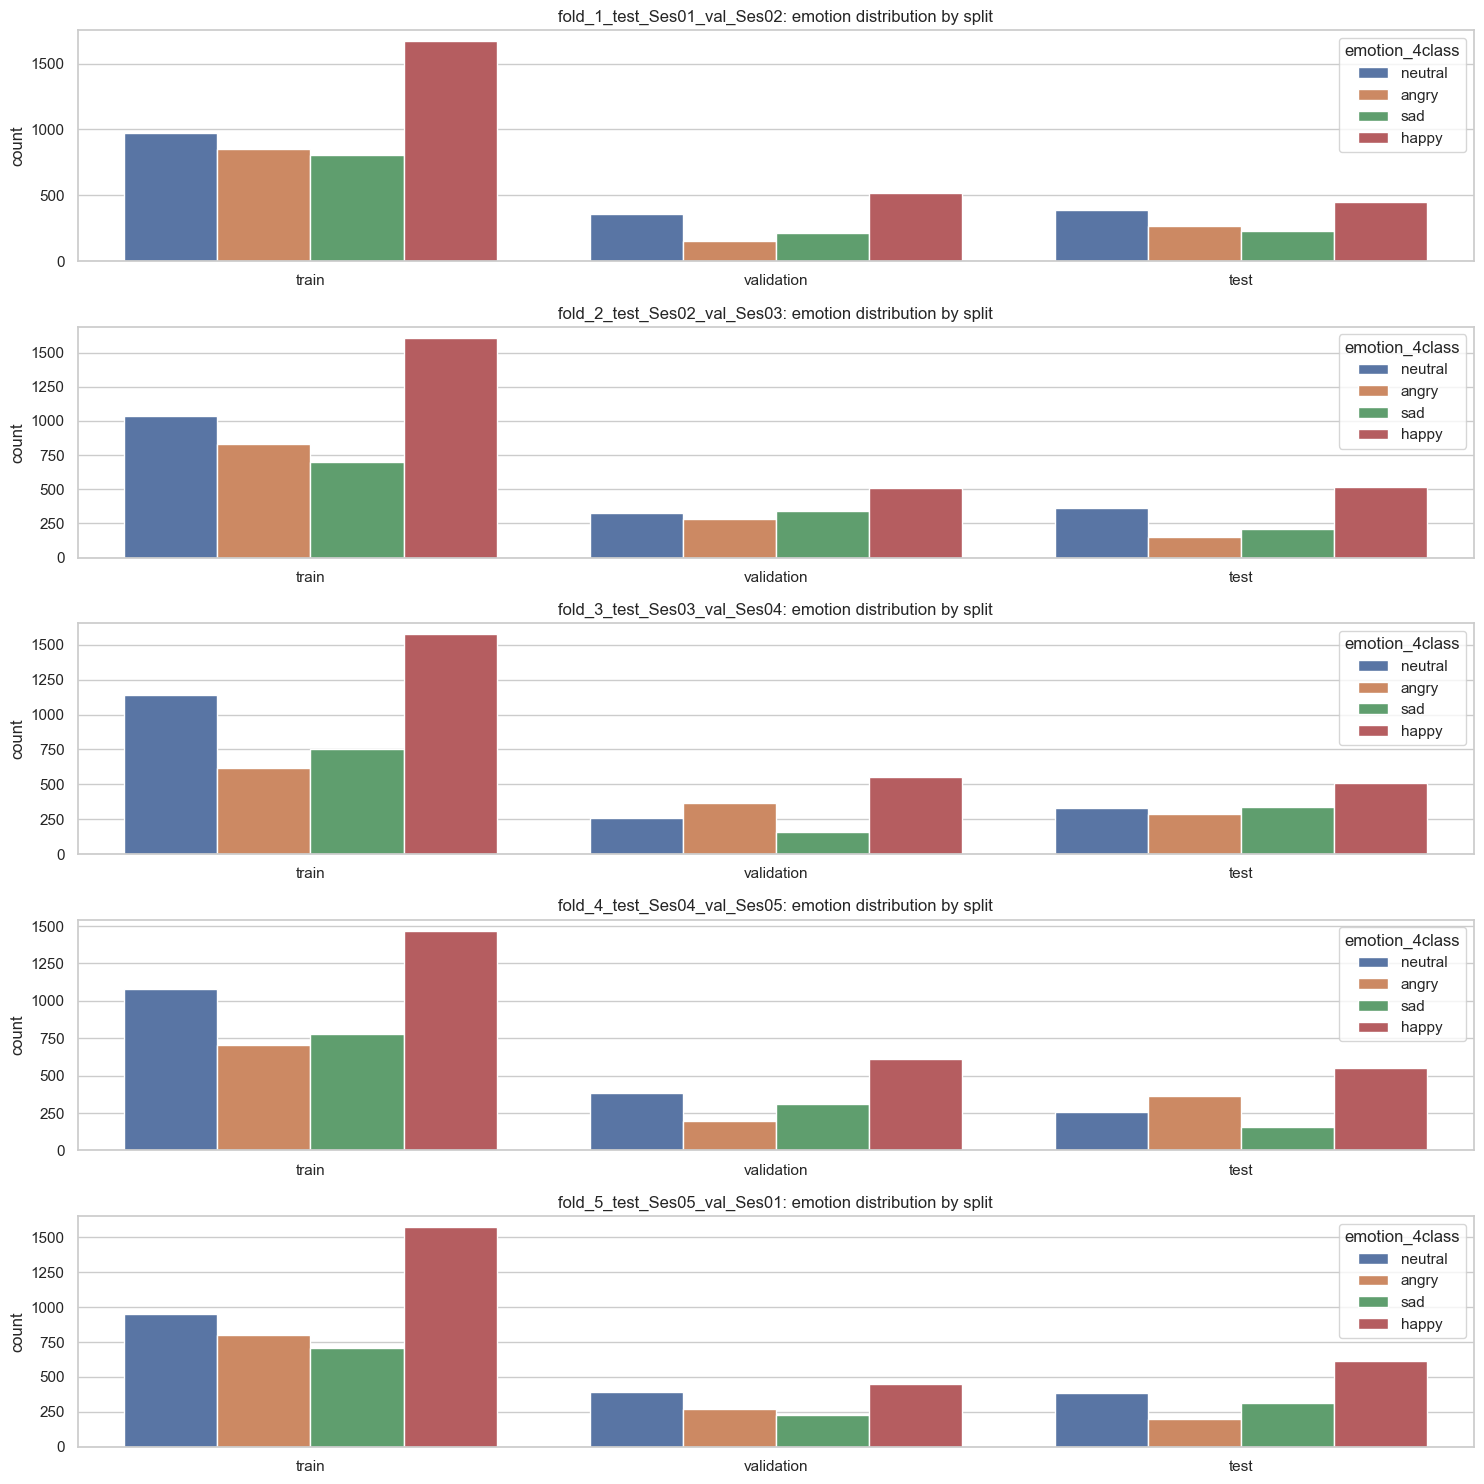

In [15]:
if train_metadata.empty or not folds_5:
    display(Markdown("Không có 5-fold split để visualize."))
else:
    split5_df = split_to_long_dataframe(folds_5, train_metadata)
    fold_order = [f["fold"] for f in folds_5]
    fig, axes = plt.subplots(len(fold_order), 1, figsize=(15, max(4, 3 * len(fold_order))), sharex=False)
    if len(fold_order) == 1:
        axes = [axes]
    for ax, fold_name in zip(axes, fold_order):
        sub = split5_df[split5_df["fold"] == fold_name]
        sns.countplot(data=sub, x="split", hue="emotion_4class", hue_order=FOUR_CLASS_EMOTIONS, ax=ax)
        ax.set_title(f"{fold_name}: emotion distribution by split")
        ax.set_xlabel("")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "split_5fold_session_distribution.png", dpi=160, bbox_inches="tight")
    plt.show()

## 14. 10-fold speaker-independent split

Thiết kế mặc định:

```text
Mỗi fold:
  test = 1 speaker
  validation = 1 speaker khác
  train = 8 speakers còn lại
```

Đây là split khó và quan trọng nhất cho hướng đề tài hiện tại, vì test speaker hoàn toàn chưa xuất hiện trong train.

In [16]:
if train_metadata.empty:
    folds_10 = []
    display(Markdown("Không có train metadata để tạo 10-fold split."))
else:
    speakers = sorted(train_metadata["speaker_id"].unique().tolist())
    if len(speakers) != 10:
        display(Markdown(f"**Cảnh báo:** kỳ vọng IEMOCAP có 10 speakers, nhưng tìm thấy {len(speakers)} speakers: `{speakers}`"))

    folds_10, leakage_10, fold_rows = [], [], []

    for i, test_speaker in enumerate(speakers):
        val_speaker = speakers[(i + 1) % len(speakers)]
        train_speakers = [s for s in speakers if s not in {test_speaker, val_speaker}]

        train_idx = train_metadata.index[train_metadata["speaker_id"].isin(train_speakers)].to_numpy()
        val_idx = train_metadata.index[train_metadata["speaker_id"].eq(val_speaker)].to_numpy()
        test_idx = train_metadata.index[train_metadata["speaker_id"].eq(test_speaker)].to_numpy()
        fold_name = f"fold_{i+1}_test_{test_speaker}_val_{val_speaker}"

        folds_10.append(make_fold_record(fold_name, train_idx, val_idx, test_idx, train_metadata))
        leakage = check_split_leakage(train_metadata, train_idx, val_idx, test_idx)
        leakage["fold"] = fold_name
        leakage_10.append(leakage)

        for split_name, idx in [("train", train_idx), ("validation", val_idx), ("test", test_idx)]:
            sub = train_metadata.loc[idx]
            fold_rows.append({
                "fold": fold_name,
                "split": split_name,
                "n_samples": len(sub),
                "sessions": ",".join(sorted(sub["session"].unique())),
                "speakers": ",".join(sorted(sub["speaker_id"].unique())),
                **{f"n_{emo}": int((sub["emotion_4class"] == emo).sum()) for emo in FOUR_CLASS_EMOTIONS},
            })

    with (SPLIT_DIR / "iemocap_10fold_speaker.json").open("w", encoding="utf-8") as f:
        json.dump({"protocol": "10-fold speaker-independent 8/1/1", "folds": folds_10}, f, indent=2, ensure_ascii=False)

    split10_df = split_to_long_dataframe(folds_10, train_metadata)
    split10_df.to_csv(SPLIT_DIR / "iemocap_10fold_speaker_long.csv", index=False, encoding="utf-8-sig")
    summary10 = pd.DataFrame(fold_rows)
    summary10.to_csv(REPORT_DIR / "iemocap_10fold_speaker_summary.csv", index=False, encoding="utf-8-sig")
    pd.DataFrame(leakage_10).to_csv(REPORT_DIR / "iemocap_10fold_speaker_leakage_check.csv", index=False, encoding="utf-8-sig")

    display(summary10)
    display(pd.DataFrame(leakage_10))

,fold,split,n_samples,sessions,speakers,n_neutral,n_angry,n_sad,n_happy
0,fold_1_test_Ses01F_val_Ses01M,train,5540,"Ses02,Ses03,Ses04,Ses05","Ses02F,Ses02M,Ses03F,Ses03M,Ses04F,Ses04M,Ses05F,Ses05M",1334,999,1021,2186
1,fold_1_test_Ses01F_val_Ses01M,validation,680,Ses01,Ses01M,217,91,129,243
2,fold_1_test_Ses01F_val_Ses01M,test,657,Ses01,Ses01F,175,179,100,203
3,fold_2_test_Ses01M_val_Ses02F,train,5616,"Ses01,Ses02,Ses03,Ses04,Ses05","Ses01F,Ses02M,Ses03F,Ses03M,Ses04F,Ses04M,Ses05F,Ses05M",1374,1107,995,2140
4,fold_2_test_Ses01M_val_Ses02F,validation,581,Ses02,Ses02F,135,71,126,249
5,fold_2_test_Ses01M_val_Ses02F,test,680,Ses01,Ses01M,217,91,129,243
6,fold_3_test_Ses02F_val_Ses02M,train,5634,"Ses01,Ses03,Ses04,Ses05","Ses01F,Ses01M,Ses03F,Ses03M,Ses04F,Ses04M,Ses05F,Ses05M",1364,1118,1038,2114
7,fold_3_test_Ses02F_val_Ses02M,validation,662,Ses02,Ses02M,227,80,86,269
8,fold_3_test_Ses02F_val_Ses02M,test,581,Ses02,Ses02F,135,71,126,249
9,fold_4_test_Ses02M_val_Ses03F,train,5538,"Ses01,Ses02,Ses03,Ses04,Ses05","Ses01F,Ses01M,Ses02F,Ses03M,Ses04F,Ses04M,Ses05F,Ses05M",1366,1074,962,2136


,speaker_train_val_overlap,speaker_train_test_overlap,speaker_val_test_overlap,session_train_val_overlap,session_train_test_overlap,session_val_test_overlap,fold
0,[],[],[],[],[],[Ses01],fold_1_test_Ses01F_val_Ses01M
1,[],[],[],[Ses02],[Ses01],[],fold_2_test_Ses01M_val_Ses02F
2,[],[],[],[],[],[Ses02],fold_3_test_Ses02F_val_Ses02M
3,[],[],[],[Ses03],[Ses02],[],fold_4_test_Ses02M_val_Ses03F
4,[],[],[],[],[],[Ses03],fold_5_test_Ses03F_val_Ses03M
5,[],[],[],[Ses04],[Ses03],[],fold_6_test_Ses03M_val_Ses04F
6,[],[],[],[],[],[Ses04],fold_7_test_Ses04F_val_Ses04M
7,[],[],[],[Ses05],[Ses04],[],fold_8_test_Ses04M_val_Ses05F
8,[],[],[],[],[],[Ses05],fold_9_test_Ses05F_val_Ses05M
9,[],[],[],[Ses01],[Ses05],[],fold_10_test_Ses05M_val_Ses01F


## 15. Visualize 10-fold split

Vì 10-fold giữ lại từng speaker làm test, số mẫu và phân bố emotion giữa các fold có thể dao động khá nhiều. Đây là điều cần ghi nhận khi so sánh với các bài báo khác.

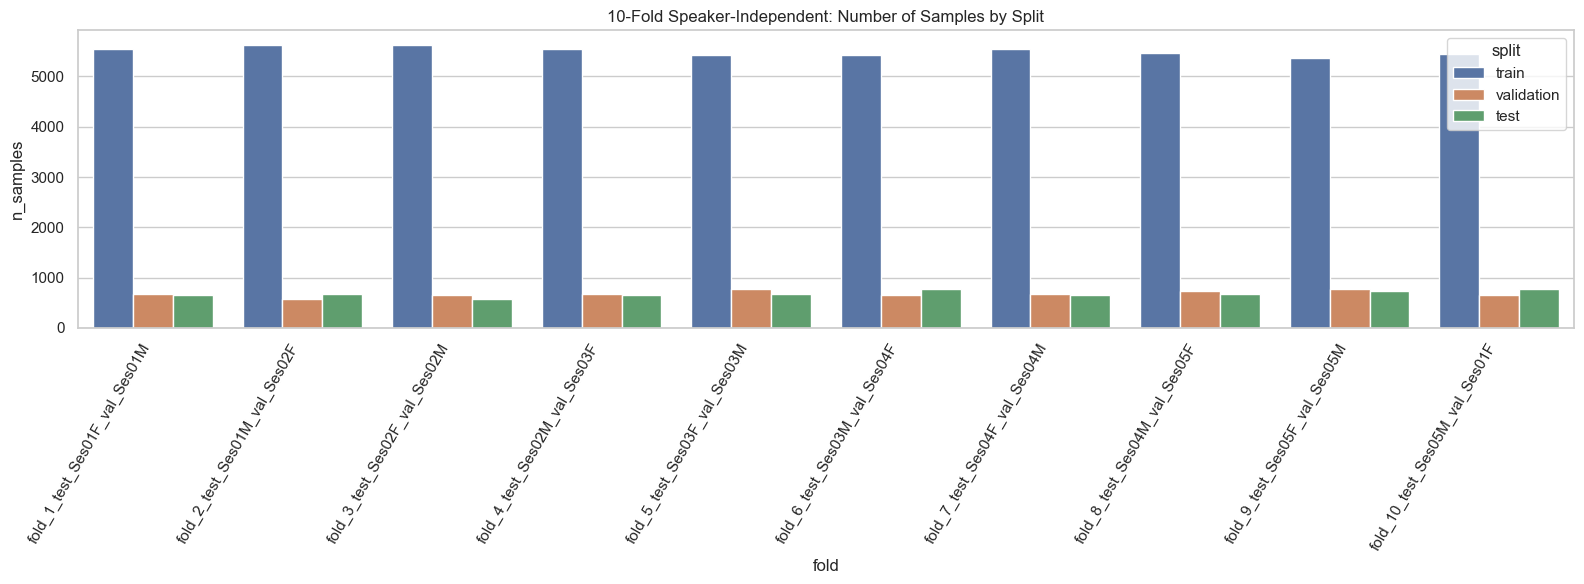

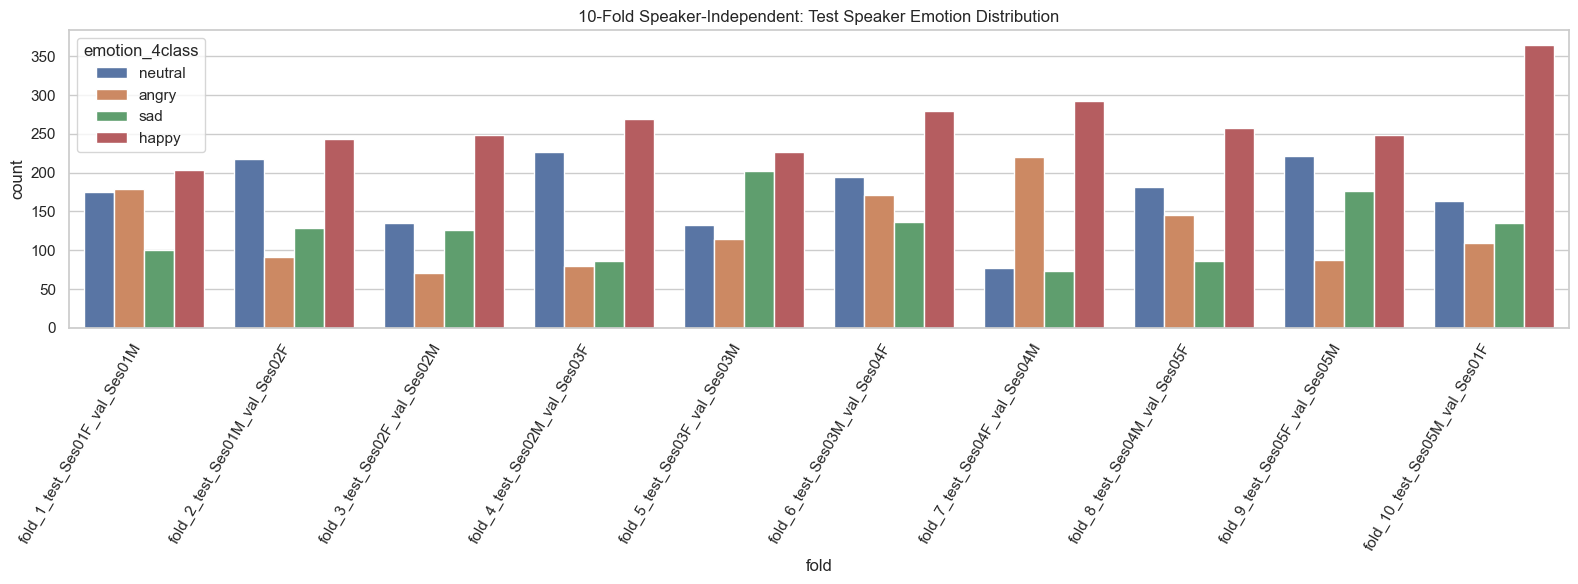

In [17]:
if train_metadata.empty or not folds_10:
    display(Markdown("Không có 10-fold split để visualize."))
else:
    split10_df = split_to_long_dataframe(folds_10, train_metadata)
    summary10 = pd.read_csv(REPORT_DIR / "iemocap_10fold_speaker_summary.csv")

    plt.figure(figsize=(16, 6))
    sns.barplot(data=summary10, x="fold", y="n_samples", hue="split")
    plt.xticks(rotation=60, ha="right")
    plt.title("10-Fold Speaker-Independent: Number of Samples by Split")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "split_10fold_sample_counts.png", dpi=160, bbox_inches="tight")
    plt.show()

    test_only = split10_df[split10_df["split"] == "test"].copy()
    plt.figure(figsize=(16, 6))
    sns.countplot(data=test_only, x="fold", hue="emotion_4class", hue_order=FOUR_CLASS_EMOTIONS)
    plt.xticks(rotation=60, ha="right")
    plt.title("10-Fold Speaker-Independent: Test Speaker Emotion Distribution")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "split_10fold_test_emotion_distribution.png", dpi=160, bbox_inches="tight")
    plt.show()

## 17. Nhận xét sau khi thống kê dataset

Sau khi chạy các cell thống kê phía trên, cần đọc kết quả theo các điểm sau:

1. **Nếu số mẫu 4-class khoảng 5,531**  
   Điều này là đúng với benchmark phổ biến. Lý do là IEMOCAP full có nhiều nhãn hơn, nhưng 4-class SER chỉ giữ `neutral`, `angry`, `sad`, `happy`, trong đó `hap` và `exc` được gộp.

2. **Nếu class `happy` lớn hơn dự kiến**  
   Hãy nhớ rằng `happy = hap + exc`, nên số mẫu happy thường tăng sau khi gộp.

3. **Nếu `frustration` có nhiều mẫu nhưng bị loại**  
   Đây là lựa chọn benchmark. Một số bài dùng 5-class hoặc 6-class có thể giữ frustration, nhưng để so với emotion2vec/CA-MSER/FT-w2v2/DST, 4-class là lựa chọn an toàn hơn.

4. **Nếu 10-fold thấp hơn 5-fold**  
   Đây là hiện tượng bình thường. 10-fold speaker-independent khó hơn vì test speaker hoàn toàn chưa thấy trong train.

5. **Nếu Valence CCC thấp hơn Arousal CCC về sau**  
   Đây cũng thường gặp trong speech-only SER. Valence đôi khi cần lexical/contextual information nhiều hơn, nên audio-only model có thể khó học Valence hơn Arousal.

6. **Nếu duration có nhiều utterance dài hơn 3 giây**  
   Không nên crop cứng 3 giây như 06D cũ. Notebook feature extraction nên dùng segment-level extraction + pooling để tránh mất tín hiệu cảm xúc ở cuối câu.

Các nhận xét này sẽ được kiểm chứng bằng output thực tế sau khi `IEMOCAP_ROOT` được cấu hình và notebook được chạy đầy đủ.

## 16. Final dataset report

Cell này tạo một file markdown tóm tắt để đưa vào báo cáo/roadmap hoặc kiểm tra nhanh sau khi chạy notebook.

In [18]:
if metadata.empty or train_metadata.empty:
    display(Markdown("Chưa thể tạo final report vì metadata rỗng."))
else:
    duration_desc = train_metadata["duration"].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99])
    crop_rates = {sec: (train_metadata["duration"] > sec).mean() for sec in [3, 4, 5, 8, 10, 15]}
    avd_mean = train_metadata[["valence", "arousal", "dominance"]].mean()
    avd_by_emotion = (
        train_metadata.groupby("emotion_4class")[["valence", "arousal", "dominance", "duration"]]
        .mean()
        .round(3)
    )
    leak5_path = REPORT_DIR / "iemocap_5fold_session_leakage_check.csv"
    leak10_path = REPORT_DIR / "iemocap_10fold_speaker_leakage_check.csv"
    leak5_df = pd.read_csv(leak5_path) if leak5_path.exists() else pd.DataFrame()
    leak10_df = pd.read_csv(leak10_path) if leak10_path.exists() else pd.DataFrame()
    leak5_any = False
    if not leak5_df.empty:
        leak5_any = (leak5_df[[c for c in leak5_df.columns if c != "fold"]].astype(str) != "[]").any().any()
    speaker_leak10 = False
    session_overlap10 = False
    if not leak10_df.empty:
        speaker_cols = [c for c in leak10_df.columns if c.startswith("speaker_")]
        session_cols = [c for c in leak10_df.columns if c.startswith("session_")]
        speaker_leak10 = (leak10_df[speaker_cols].astype(str) != "[]").any().any()
        session_overlap10 = (leak10_df[session_cols].astype(str) != "[]").any().any()

    report_lines = [
        "# IEMOCAP Dataset Analysis Summary",
        "",
        "## Data source and scope",
        "",
        "- Source used in this notebook: AbstractTTS/IEMOCAP on HuggingFace.",
        f"- Full metadata utterances: **{len(metadata):,}**.",
        f"- 4-class train-ready utterances: **{len(train_metadata):,}**.",
        f"- Sessions: **{train_metadata['session'].nunique()}**.",
        f"- Speakers: **{train_metadata['speaker_id'].nunique()}**.",
        f"- Conversations: **{train_metadata['conversation_id'].nunique()}**.",
        f"- WAV found rate in full metadata: **{metadata['wav_found'].mean():.4f}**.",
        "",
        "Important: this 4-class subset is built from the HuggingFace `major_emotion` style labels. It has "
        f"**{len(train_metadata):,}** samples, so it is not automatically the same as the canonical IEMOCAP 4-class "
        "benchmark with about 5,531 utterances used by many papers. Results should be reported as "
        "**HF-major-emotion 4-class setting** unless we reproduce the exact paper filtering rule.",
        "",
        "## 4-Class Emotion Counts",
        "",
    ]
    for emotion, count in train_metadata["emotion_4class"].value_counts().sort_index().items():
        report_lines.append(f"- {emotion}: **{count:,}**")

    report_lines += [
        "",
        "## Duration and segmentation risk",
        "",
        f"- Mean duration: **{duration_desc['mean']:.3f}s**.",
        f"- Median duration: **{duration_desc['50%']:.3f}s**.",
        f"- 75th percentile: **{duration_desc['75%']:.3f}s**.",
        f"- 95th percentile: **{duration_desc['95%']:.3f}s**.",
        f"- Max duration: **{duration_desc['max']:.3f}s**.",
        "",
        "Crop/truncation risk if a fixed-length input is used:",
    ]
    for sec, rate in crop_rates.items():
        report_lines.append(f"- Longer than {sec}s: **{rate * 100:.2f}%**")

    report_lines += [
        "",
        "Interpretation: a single 4-second truncation would discard the tail of about "
        f"**{crop_rates[4] * 100:.2f}%** of 4-class utterances. For emotion2vec/wav2vec2-style models, a safer design is "
        "segment-level encoding followed by utterance-level pooling or attention.",
        "",
        "## Valence, arousal, dominance",
        "",
        "The AVD labels are continuous annotation scores on a 1-5 scale. This notebook also keeps normalized "
        "`*_norm` columns on a 0-1 scale for regression.",
        "",
        f"- Mean valence: **{avd_mean['valence']:.3f}**.",
        f"- Mean arousal: **{avd_mean['arousal']:.3f}**.",
        f"- Mean dominance: **{avd_mean['dominance']:.3f}**.",
        "",
        "Average AVD by emotion:",
        "",
        avd_by_emotion.to_markdown(),
        "",
        "Interpretation: angry has low valence and high arousal/dominance; happy has the highest valence; sad has lower "
        "valence/arousal; neutral stays near the center. This supports the multi-task idea, but emotion classification "
        "and AVD regression should still be evaluated with different metrics.",
        "",
        "## Speaker-independent split checks",
        "",
        f"- 5-fold session split leakage detected: **{leak5_any}**.",
        f"- 10-fold speaker split speaker leakage detected: **{speaker_leak10}**.",
        f"- 10-fold speaker split has session overlap: **{session_overlap10}**.",
        "",
        "Interpretation: the 5-fold protocol is stricter at the session level. The 10-fold protocol is speaker-independent "
        "because test speakers do not appear in train/validation, but it can still share the same session context through "
        "the other speaker.",
        "",
        "## Output files",
        "",
        f"- Metadata full: `{METADATA_DIR / 'iemocap_metadata_full.csv'}`",
        f"- Metadata 4-class + AVD: `{METADATA_DIR / 'iemocap_4class_avd_metadata.csv'}`",
        f"- 5-fold split JSON: `{SPLIT_DIR / 'iemocap_5fold_session.json'}`",
        f"- 10-fold split JSON: `{SPLIT_DIR / 'iemocap_10fold_speaker.json'}`",
        f"- Figures generated: **{len(list(FIGURE_DIR.glob('*.png')))}**.",
        f"- Report/table files generated: **{len(list(REPORT_DIR.glob('*')))}**.",
        "",
        "## Final note for the next notebook",
        "",
        "Notebook 02 should not blindly truncate all utterances to 4 seconds. It should preserve segment-level information "
        "and later aggregate features at utterance level for 5-fold and 10-fold training.",
    ]

    report_path = REPORT_DIR / "IEMOCAP_dataset_analysis_summary.md"
    report_path.write_text("\n".join(report_lines), encoding="utf-8")
    audit_path = REPORT_DIR / "notebook01_output_audit_and_interpretation.md"
    audit_path.write_text("\n".join(report_lines), encoding="utf-8")
    display(Markdown("\n".join(report_lines)))
    print("Saved report:", report_path)
    print("Saved audit:", audit_path)


# IEMOCAP Dataset Analysis Summary

## Data source and scope

- Source used in this notebook: AbstractTTS/IEMOCAP on HuggingFace.
- Full metadata utterances: **10,039**.
- 4-class train-ready utterances: **6,877**.
- Sessions: **5**.
- Speakers: **10**.
- Conversations: **110**.
- WAV found rate in full metadata: **1.0000**.

Important: this 4-class subset is built from the HuggingFace `major_emotion` style labels. It has **6,877** samples, so it is not automatically the same as the canonical IEMOCAP 4-class benchmark with about 5,531 utterances used by many papers. Results should be reported as **HF-major-emotion 4-class setting** unless we reproduce the exact paper filtering rule.

## 4-Class Emotion Counts

- angry: **1,269**
- happy: **2,632**
- neutral: **1,726**
- sad: **1,250**

## Duration and segmentation risk

- Mean duration: **4.486s**.
- Median duration: **3.530s**.
- 75th percentile: **5.714s**.
- 95th percentile: **10.709s**.
- Max duration: **34.139s**.

Crop/truncation risk if a fixed-length input is used:
- Longer than 3s: **59.76%**
- Longer than 4s: **42.74%**
- Longer than 5s: **31.23%**
- Longer than 8s: **11.85%**
- Longer than 10s: **6.28%**
- Longer than 15s: **1.25%**

Interpretation: a single 4-second truncation would discard the tail of about **42.74%** of 4-class utterances. For emotion2vec/wav2vec2-style models, a safer design is segment-level encoding followed by utterance-level pooling or attention.

## Valence, arousal, dominance

The AVD labels are continuous annotation scores on a 1-5 scale. This notebook also keeps normalized `*_norm` columns on a 0-1 scale for regression.

- Mean valence: **2.976**.
- Mean arousal: **3.079**.
- Mean dominance: **3.171**.

Average AVD by emotion:

| emotion_4class   |   valence |   arousal |   dominance |   duration |
|:-----------------|----------:|----------:|------------:|-----------:|
| angry            |     1.935 |     3.599 |       3.891 |      4.554 |
| happy            |     3.805 |     3.285 |       3.202 |      4.443 |
| neutral          |     2.984 |     2.729 |       2.854 |      3.903 |
| sad              |     2.277 |     2.6   |       2.812 |      5.309 |

Interpretation: angry has low valence and high arousal/dominance; happy has the highest valence; sad has lower valence/arousal; neutral stays near the center. This supports the multi-task idea, but emotion classification and AVD regression should still be evaluated with different metrics.

## Speaker-independent split checks

- 5-fold session split leakage detected: **False**.
- 10-fold speaker split speaker leakage detected: **False**.
- 10-fold speaker split has session overlap: **True**.

Interpretation: the 5-fold protocol is stricter at the session level. The 10-fold protocol is speaker-independent because test speakers do not appear in train/validation, but it can still share the same session context through the other speaker.

## Output files

- Metadata full: `D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\01IEMOCAP Dataset Analysis and Speaker-Independent Splits\metadata\iemocap_metadata_full.csv`
- Metadata 4-class + AVD: `D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\01IEMOCAP Dataset Analysis and Speaker-Independent Splits\metadata\iemocap_4class_avd_metadata.csv`
- 5-fold split JSON: `D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\01IEMOCAP Dataset Analysis and Speaker-Independent Splits\splits\iemocap_5fold_session.json`
- 10-fold split JSON: `D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\01IEMOCAP Dataset Analysis and Speaker-Independent Splits\splits\iemocap_10fold_speaker.json`
- Figures generated: **8**.
- Report/table files generated: **18**.

## Final note for the next notebook

Notebook 02 should not blindly truncate all utterances to 4 seconds. It should preserve segment-level information and later aggregate features at utterance level for 5-fold and 10-fold training.

Saved report: D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\01IEMOCAP Dataset Analysis and Speaker-Independent Splits\reports\IEMOCAP_dataset_analysis_summary.md
Saved audit: D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\01IEMOCAP Dataset Analysis and Speaker-Independent Splits\reports\notebook01_output_audit_and_interpretation.md


## 17. Kết luận cho bước 1

Sau khi chạy xong notebook này, các notebook tiếp theo sẽ dùng:

```text
06_w2v_based_models/metadata/iemocap_4class_avd_metadata.csv
06_w2v_based_models/splits/iemocap_5fold_session.json
06_w2v_based_models/splits/iemocap_10fold_speaker.json
```

Notebook tiếp theo:

```text
IEMOCAP_Feature_Extraction_Emotion2Vec_Acoustic.ipynb
```

Mục tiêu notebook tiếp theo là trích emotion2vec tokens/embeddings, MFCC, log-Mel, prosody features và statistical functionals.

<!-- CODEx output audit v2 -->

## 12. Kiểm tra output sau khi có metadata và audio HF

Phần này là phần audit sau khi notebook đã chạy thật trên metadata/audio tải từ [AbstractTTS/IEMOCAP](https://huggingface.co/datasets/AbstractTTS/IEMOCAP), không chỉ là mô tả kế hoạch.

### Trạng thái dữ liệu

- Metadata đầy đủ có **10,039 utterances**.
- Subset 4 lớp dùng cho emotion classification hiện có **6,877 utterances** với nhãn `neutral`, `angry`, `sad`, `happy`; trong đó `happy` đã gộp cả `happy` và `excited`.
- Tất cả dòng trong subset 4 lớp đều có đường dẫn WAV đã xuất từ HuggingFace.
- Phân bố nhãn 4 lớp: **happy: 2632, neutral: 1726, angry: 1269, sad: 1250**.
- Phân bố session: **Ses01: 1337, Ses02: 1243, Ses03: 1458, Ses04: 1332, Ses05: 1507**.
- Phân bố giới tính: **male: 3566, female: 3311**.

Điểm cần ghi rất rõ: con số **6,877** này là subset theo `major_emotion` của bản HuggingFace, không phải đúng benchmark 4-class **5,531 utterances** thường thấy trong nhiều bài IEMOCAP. Vì vậy, khi báo cáo kết quả, cần ghi là **HF-major-emotion 4-class setting**. Nếu muốn so trực tiếp với paper dùng 5,531 mẫu, ta phải tái tạo đúng tiêu chí consensus/label filtering của paper đó.

### Độ dài audio và ảnh hưởng tới feature extraction

- Độ dài trung bình: **4.486 giây**.
- Median: **3.530 giây**.
- 75% utterance ngắn hơn **5.714 giây**.
- 95% utterance ngắn hơn **10.709 giây**.
- Audio dài nhất trong subset: **34.139 giây**.
- Tỷ lệ audio dài hơn mốc cố định: **>3s: 59.76%, >4s: 42.74%, >5s: 31.23%, >8s: 11.85%, >10s: 6.28%, >15s: 1.25%**.

Nhận xét: nếu mô hình dùng một cửa sổ cố định 4 giây và chỉ truncate, khoảng **42.74%** mẫu sẽ bị mất thông tin cuối câu. Vì vậy notebook feature ở bước 02 nên dùng segmentation/pooling thay vì cắt cụt một đoạn duy nhất. Với emotion2vec hoặc wav2vec2, hướng hợp lý là chia thành segment ngắn, lấy embedding từng segment, sau đó attention/mean pooling theo utterance.

### Valence, arousal, dominance trong dữ liệu này

Các cột `valence`, `arousal`, `dominance` nằm trên thang **1-5** từ annotation IEMOCAP; notebook cũng tạo bản chuẩn hóa `*_norm` về khoảng 0-1 để thuận tiện cho regression.

- Valence trung bình: **2.976**.
- Arousal trung bình: **3.079**.
- Dominance trung bình: **3.171**.

Trung bình AVD theo emotion:

| emotion_4class   |   valence |   arousal |   dominance |   duration |
|:-----------------|----------:|----------:|------------:|-----------:|
| angry            |     1.935 |     3.599 |       3.891 |      4.554 |
| happy            |     3.805 |     3.285 |       3.202 |      4.443 |
| neutral          |     2.984 |     2.729 |       2.854 |      3.903 |
| sad              |     2.277 |     2.6   |       2.812 |      5.309 |

Nhận xét từ thống kê này phù hợp với trực giác cảm xúc: `angry` có arousal/dominance cao và valence thấp; `happy` có valence cao; `sad` có valence và arousal thấp hơn; `neutral` nằm gần vùng trung tính. Đây là lý do task emotion classification và AVD regression có liên quan, nhưng không hoàn toàn giống nhau: một bên dự đoán lớp rời rạc, một bên dự đoán tọa độ cảm xúc liên tục.

### Kiểm tra split speaker-independent

- **5-fold session split**: không có overlap speaker/session giữa train, validation và test (`leakage_check` không phát hiện leak). Đây là split nghiêm ngặt theo session, thường khó hơn vì test session hoàn toàn mới.
- **10-fold speaker split**: không có speaker overlap giữa train, validation và test. Tuy nhiên có session overlap ở một số fold vì hai speaker trong cùng session có thể nằm ở các split khác nhau. Điều này vẫn đúng với mục tiêu **speaker-independent**, nhưng không phải **session-independent**.
- Output split đã được lưu thành JSON và CSV long format để notebook train có thể đọc lại trực tiếp.

### File output đã sinh ra

- Figures: **8** file PNG.
- Reports/tables: **17** file.
- Split files: **4** file.

Kết luận cho notebook 01: dữ liệu đã sẵn sàng cho hai protocol chính, nhưng khi viết báo cáo cần tách rõ hai ngữ cảnh: **5-fold session-independent** để đánh giá nghiêm ngặt hơn, và **10-fold speaker-independent** để đối chiếu với các bài dùng 8 speakers train, 1 validation, 1 test.
